# HCR Cell×Gene Viewer (Raw Counts, Leiden-Named Clusters)

Loads a mouse's pairwise unmixed cell×gene table and plots it ordered by
the Leiden-named cluster assignments from the matching pipeline.

Uses raw spot counts (not z-scored) for interpretability.

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path

from aind_hcr_data_loader import get_hcr_dataset_pairwise
import aind_hcr_qc.viz as viz


# notebook setup
data_dir = Path('/root/capsule/data')
bucket_name = "aind-open-data"

# notebook configuration
%matplotlib inline
%load_ext autoreload
%autoreload 2


# Load data

In [25]:
# Branch color palette — colors the cluster text labels by subclass
BRANCH_COLORS = {
    "Pvalb": "#1f77b4",  # blue
    "Sst": "#d62728",    # red
    "Vip": "#2ca02c",    # green
    "Lamp5": "#ff7f0e",  # orange
}

# ============ SETTINGS ============
MOUSE_ID = "788406"
DATA_DIR = Path("/root/capsule/data")
RESULTS_DIR = Path("/root/capsule/scratch/hcr_tasic_matching/stage5")
ASSIGNMENTS_FILE = RESULTS_DIR / "hcr_assignments_leiden_named.csv"

# Use log1p transform for visual comparison with Tasic (log CP10K scale)
LOG_TRANSFORM = False

# Clip range for the heatmap
CLIP_RANGE = (0, 8) if LOG_TRANSFORM else (0, 200)

# Minimum Pearson correlation to best centroid to keep a cell
MIN_CONFIDENCE = 0.1

COREG_CELLS_ONLY = True

In [26]:
# Load pairwise unmixed cell x gene (raw counts)
ds, pw_ds, _ = get_hcr_dataset_pairwise(
    mouse_id=MOUSE_ID,
    data_dir=DATA_DIR,
    load_spots=False,
    return_removed=False,
    coreg_cells_only=True,
)
coreg_cells = ds.load_coreg_table()

adata = pw_ds.load_inhibitory_cells(unmixed=True, all_spots=False, as_anndata=True)

if COREG_CELLS_ONLY:
    adata = adata[adata.obs_names.isin(coreg_cells["hcr_id"].astype(str))]

# Build cell×gene DataFrame
X = adata.X if not hasattr(adata.X, "toarray") else adata.X.toarray()

if LOG_TRANSFORM:
    # log1p on raw counts (no library-size normalization — same as pipeline Stage 1 for HCR)
    X = np.log1p(X)
    scale_label = "log1p(spot count)"
else:
    scale_label = "Spot count"

cxg = pd.DataFrame(X, columns=adata.var_names, index=adata.obs_names)

# Prefix cell IDs to match the assignment table format
cxg.index = [f"{MOUSE_ID}_{cid}" for cid in cxg.index]

print(f"Loaded {cxg.shape[0]} cells × {cxg.shape[1]} genes ({scale_label})")
cxg.head()

  [rounds.R1]  HCR_788406_2025-11-05_13-00-00_processed_2025-11-10_20-35-28  →  ✓ attached
  [rounds.R2]  HCR_788406_2025-11-12_15-00-00_processed_2025-11-13_23-00-45  →  ✓ attached
  [rounds.R3]  HCR_788406_2025-11-19_13-00-00_processed_2025-11-21_01-27-21  →  ✓ attached
  [rounds.R4]  HCR_788406_2025-12-03_13-00-00_processed_2025-12-05_22-31-35  →  ✓ attached
  [rounds.R5]  HCR_788406_2025-12-11_13-00-00_processed_2025-12-13_01-51-45  →  ✓ attached
  [derived_assets.roi_shape_metrics]  HCR_788406_2025-11-05_13-00-00_roi-shape-metrics  →  ✓ attached
  [derived_assets.cell_typing]  HCR_788406_cell-typing_2026-03-11_12-00-00  →  ✓ attached
  [derived_assets.pairwise_unmixing]  HCR_788406_pairwise-unmixing_2026-05-23_17-43-01  →  ✓ attached
  [derived_assets.czstack_hcr_coreg]  788406_2025-07-18_ctl-czstack-hcr-coreg_2026-03-02_00-00-00  →  ✓ attached
[DEBUG get_spot_files] key=R1 round_num=1
[DEBUG get_spot_files] folder_path=/root/capsule/data/HCR_788406_2025-11-05_13-00-00_processed_2

gene,GFP,Slc17a7,Ndnf,Hpse,Pthlh,Chat,Tac1,Calb1,Mme,Crh,...,Lamp5,Calb2,Pdyn,Penk,Gad2,Npy,Pvalb,Cck,Sst,Vip
788406_5331,55.0,0.0,22.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,12.0,0.0,0.0,3.0,23.0,0.0,0.0,1.0,0.0,0.0
788406_5626,66.0,0.0,32.0,0.0,0.0,0.0,0.0,4.0,0.0,0.0,...,13.0,0.0,0.0,0.0,19.0,0.0,0.0,2.0,0.0,0.0
788406_7050,617.0,4.0,21.0,5.0,31.0,23.0,6.0,19.0,7.0,22.0,...,135.0,8.0,8.0,41.0,279.0,49.0,21.0,92.0,15.0,4.0
788406_7390,280.0,1.0,72.0,1.0,16.0,14.0,2.0,8.0,3.0,2.0,...,96.0,3.0,2.0,6.0,144.0,58.0,4.0,17.0,3.0,3.0
788406_7453,356.0,0.0,74.0,2.0,24.0,17.0,4.0,21.0,8.0,4.0,...,152.0,10.0,12.0,19.0,244.0,49.0,12.0,115.0,4.0,2.0


# Load clusters and filter
(confidences and cluster assignment)

In [27]:
# Load Leiden-named assignments
assignments = pd.read_csv(ASSIGNMENTS_FILE)

# Filter to this mouse
mouse_assignments = assignments[assignments["mouse_id"] == int(MOUSE_ID)].copy()
print(f"Assignments for mouse {MOUSE_ID}: {len(mouse_assignments)} cells")

# Filter by confidence
n_before = len(mouse_assignments)
mouse_assignments = mouse_assignments[mouse_assignments["confidence"] >= MIN_CONFIDENCE]
n_dropped = n_before - len(mouse_assignments)
print(f"Dropped {n_dropped} low-confidence cells (r < {MIN_CONFIDENCE}), "
      f"{len(mouse_assignments)} remaining")
print(f"  Confidence range: {mouse_assignments['confidence'].min():.3f} – "
      f"{mouse_assignments['confidence'].max():.3f} "
      f"(mean {mouse_assignments['confidence'].mean():.3f})")

# Build label Series indexed by cell_id
labels = mouse_assignments.set_index("cell_id")["assignment"]

# Keep only cells that have assignments
shared_cells = cxg.index.intersection(labels.index)
cxg_assigned = cxg.loc[shared_cells]
labels_assigned = labels.loc[shared_cells]

# Drop GFP if present
if "GFP" in cxg_assigned.columns:
    cxg_assigned = cxg_assigned.drop(columns=["GFP"])

print(f"\nCells with assignments: {len(cxg_assigned)}")
print(f"\nCluster counts:")
print(labels_assigned.value_counts().to_string())

Assignments for mouse 788406: 8455 cells
Dropped 2 low-confidence cells (r < 0.1), 8453 remaining
  Confidence range: 0.117 – 0.952 (mean 0.664)

Cells with assignments: 527

Cluster counts:
assignment
Pvalb-1: Tac1-Cck          133
Pvalb-2: Pthlh-Cck         101
Vip-4: Cck-Tac2-Crh         34
Sst-1: Calb2-Npy-Mme        28
Lamp5-4: Cck-Npy            26
Vip-3: Pthlh                26
Pvalb-0: Calb1-Npy-Tac1     24
Vip-1: Tac2-Chat            22
Lamp5-3: Pthlh-Ndnf         16
Lamp5-0: Npy                11
Sst-7: Crh-Ndnf-Cck         11
Sst-3: Hpse-Pdyn-Reln       11
Vip-5: Npy-Tac2-Crh         10
Vip-6: Chat-Calb2-Pthlh      8
Lamp5-6: Tac2-Penk           8
Sst-10: Crh-Npy              7
Lamp5-2: Cck-Crh             7
Vip-0: Crh-Pthlh             7
Sst-11: Reln-Calb1           6
Lamp5-1: Cck-Ndnf-Reln       6
Vip-2: Reln-Mme-Calb2        5
Sst-0: Tac1-Mme-Npy          5
Vip-7: Penk-Pthlh-Calb2      3
Sst-5: Pdyn-Reln-Calb1       3
Lamp5-5: Ndnf-Reln           2
Sst-4: Pdyn-Calb1-Reln 

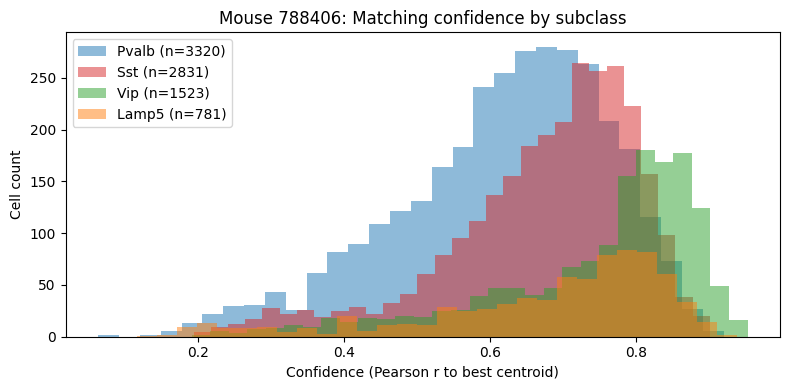

In [28]:
import matplotlib.pyplot as plt

# Confidence distribution per subclass (before filtering)
all_mouse = assignments[assignments["mouse_id"] == int(MOUSE_ID)].copy()
all_mouse["branch"] = all_mouse["assignment"].str.split("-").str[0]

branches = ["Pvalb", "Sst", "Vip", "Lamp5"]
fig, ax = plt.subplots(figsize=(8, 4))

for branch in branches:
    data = all_mouse.loc[all_mouse["branch"] == branch, "confidence"]
    if len(data) > 0:
        ax.hist(data, bins=30, alpha=0.5, label=f"{branch} (n={len(data)})",
                color=BRANCH_COLORS[branch])

# ax.axvline(MIN_CONFIDENCE, color="k", linestyle="--", linewidth=1.5,
#            label=f"threshold = {MIN_CONFIDENCE}")
ax.set_xlabel("Confidence (Pearson r to best centroid)")
ax.set_ylabel("Cell count")
ax.set_title(f"Mouse {MOUSE_ID}: Matching confidence by subclass")
ax.legend()
plt.tight_layout()

# Plot cell x gene

## HCR w/ leiden (all)

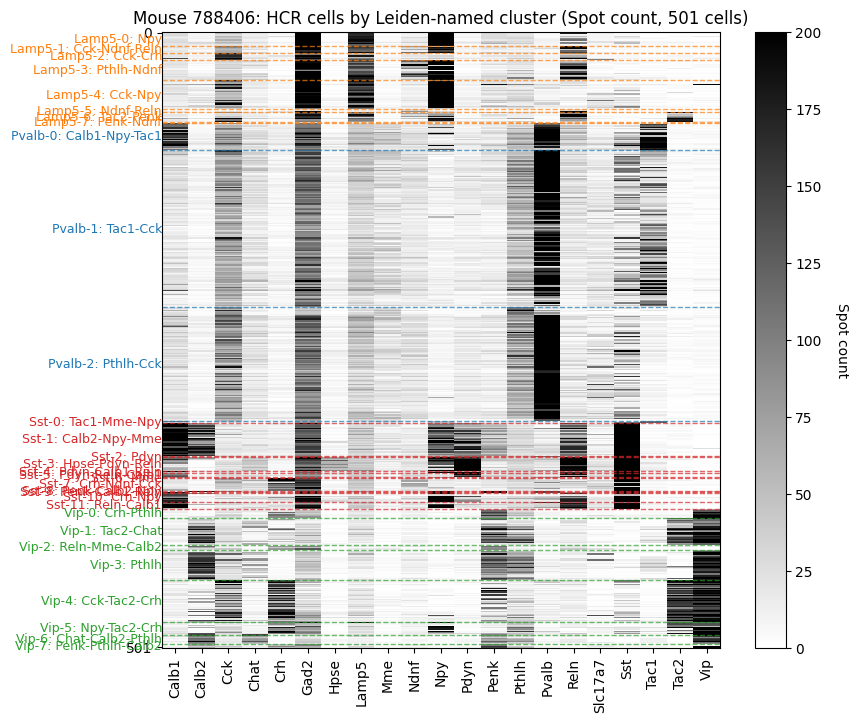

In [7]:


# Plot cell×gene heatmap with colored Leiden-named labels
fig_h = max(8, len(cxg_assigned) * 0.002)

fig, sorted_labels, sorted_cells = viz.plot_cell_x_gene_labeled(
    cxg_assigned,
    labels=labels_assigned,
    clip_range=CLIP_RANGE,
    fig_size=(9, fig_h),
    label_fontsize=9,
    cbar_label=scale_label,
    title=f"Mouse {MOUSE_ID}: HCR cells by Leiden-named cluster ({scale_label}, {len(cxg_assigned)} cells)",
    color_labels=BRANCH_COLORS,
)

## HCR with leiden (by subclass)

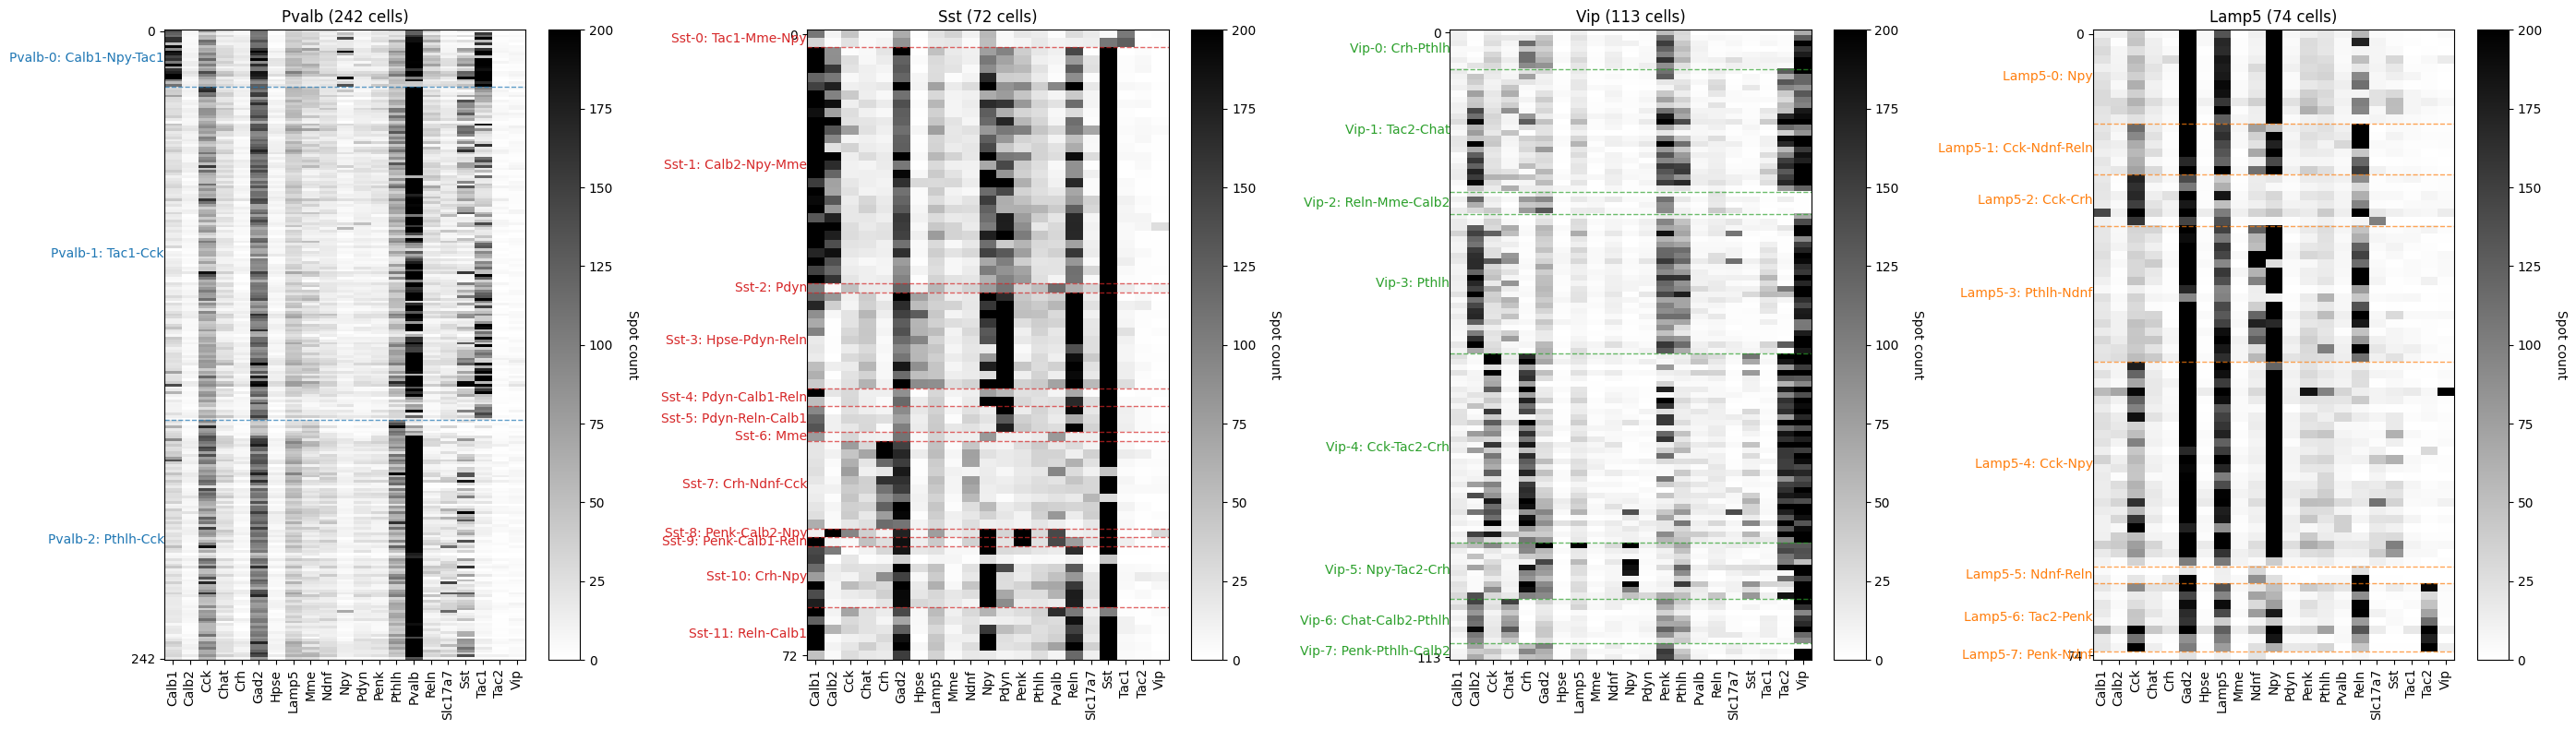

In [8]:
# Plot each subclass side by side
import matplotlib.pyplot as plt

branches = ["Pvalb", "Sst", "Vip", "Lamp5"]

# Split cells by branch
branch_data = {}
for branch in branches:
    mask = labels_assigned.str.startswith(branch + "-")
    if mask.any():
        branch_data[branch] = (cxg_assigned.loc[mask], labels_assigned.loc[mask])

n_branches = len(branch_data)
fig, axes = plt.subplots(1, n_branches, figsize=(7 * n_branches, 8))
if n_branches == 1:
    axes = [axes]

for ax, (branch, (branch_cxg, branch_labels)) in zip(axes, branch_data.items()):
    viz.plot_cell_x_gene_labeled(
        branch_cxg,
        labels=branch_labels,
        clip_range=CLIP_RANGE,
        fig_size=(5, 10),
        label_fontsize=10,
        cbar_label=scale_label,
        title=f"{branch} ({len(branch_cxg)} cells)",
        ax=ax,
        color_labels={branch: BRANCH_COLORS[branch]},
    )

plt.tight_layout()

## Tasic with leiden

In [56]:
import anndata as ad

# Load Tasic branch h5ad files saved by the pipeline (stage4)
STAGE4_DIR = Path("/root/capsule/scratch/hcr_tasic_matching/stage4")
canonical = ["Pvalb", "Sst", "Vip", "Lamp5"]

tasic_branch_data = {}
for branch in canonical:
    h5_path = STAGE4_DIR / branch.lower() / f"{branch}_branch_tasic.h5ad"
    names_path = STAGE4_DIR / branch.lower() / f"{branch}_cluster_names.csv"
    if not h5_path.exists():
        continue

    adata_br = ad.read_h5ad(h5_path)

    # Use log-normalized layer (not z-scored) for interpretable heatmap
    X_log = adata_br.layers["log_norm"] if "log_norm" in adata_br.layers else adata_br.X
    X_log = X_log if not hasattr(X_log, "toarray") else X_log.toarray()
    cxg_br = pd.DataFrame(X_log, columns=adata_br.var_names, index=adata_br.obs_names)

    # Load marker-derived cluster names
    names_df = pd.read_csv(names_path)
    name_map = dict(zip(names_df["branch_cluster"], names_df["marker_name"]))

    # Map branch_cluster → Leiden-named label (convert to str to avoid Categorical issues)
    branch_clusters = adata_br.obs["branch_cluster"].astype(str)
    labels_br = branch_clusters.map(name_map).fillna(branch_clusters)
    labels_br.name = "assignment"

    tasic_branch_data[branch] = (cxg_br, labels_br)
    print(f"{branch}: {len(cxg_br)} cells, {labels_br.nunique()} clusters")

print(f"\nLoaded Tasic Leiden clusters from stage4 output")

Pvalb: 1135 cells, 3 clusters
Sst: 1365 cells, 12 clusters
Vip: 1567 cells, 8 clusters
Lamp5: 1071 cells, 8 clusters

Loaded Tasic Leiden clusters from stage4 output


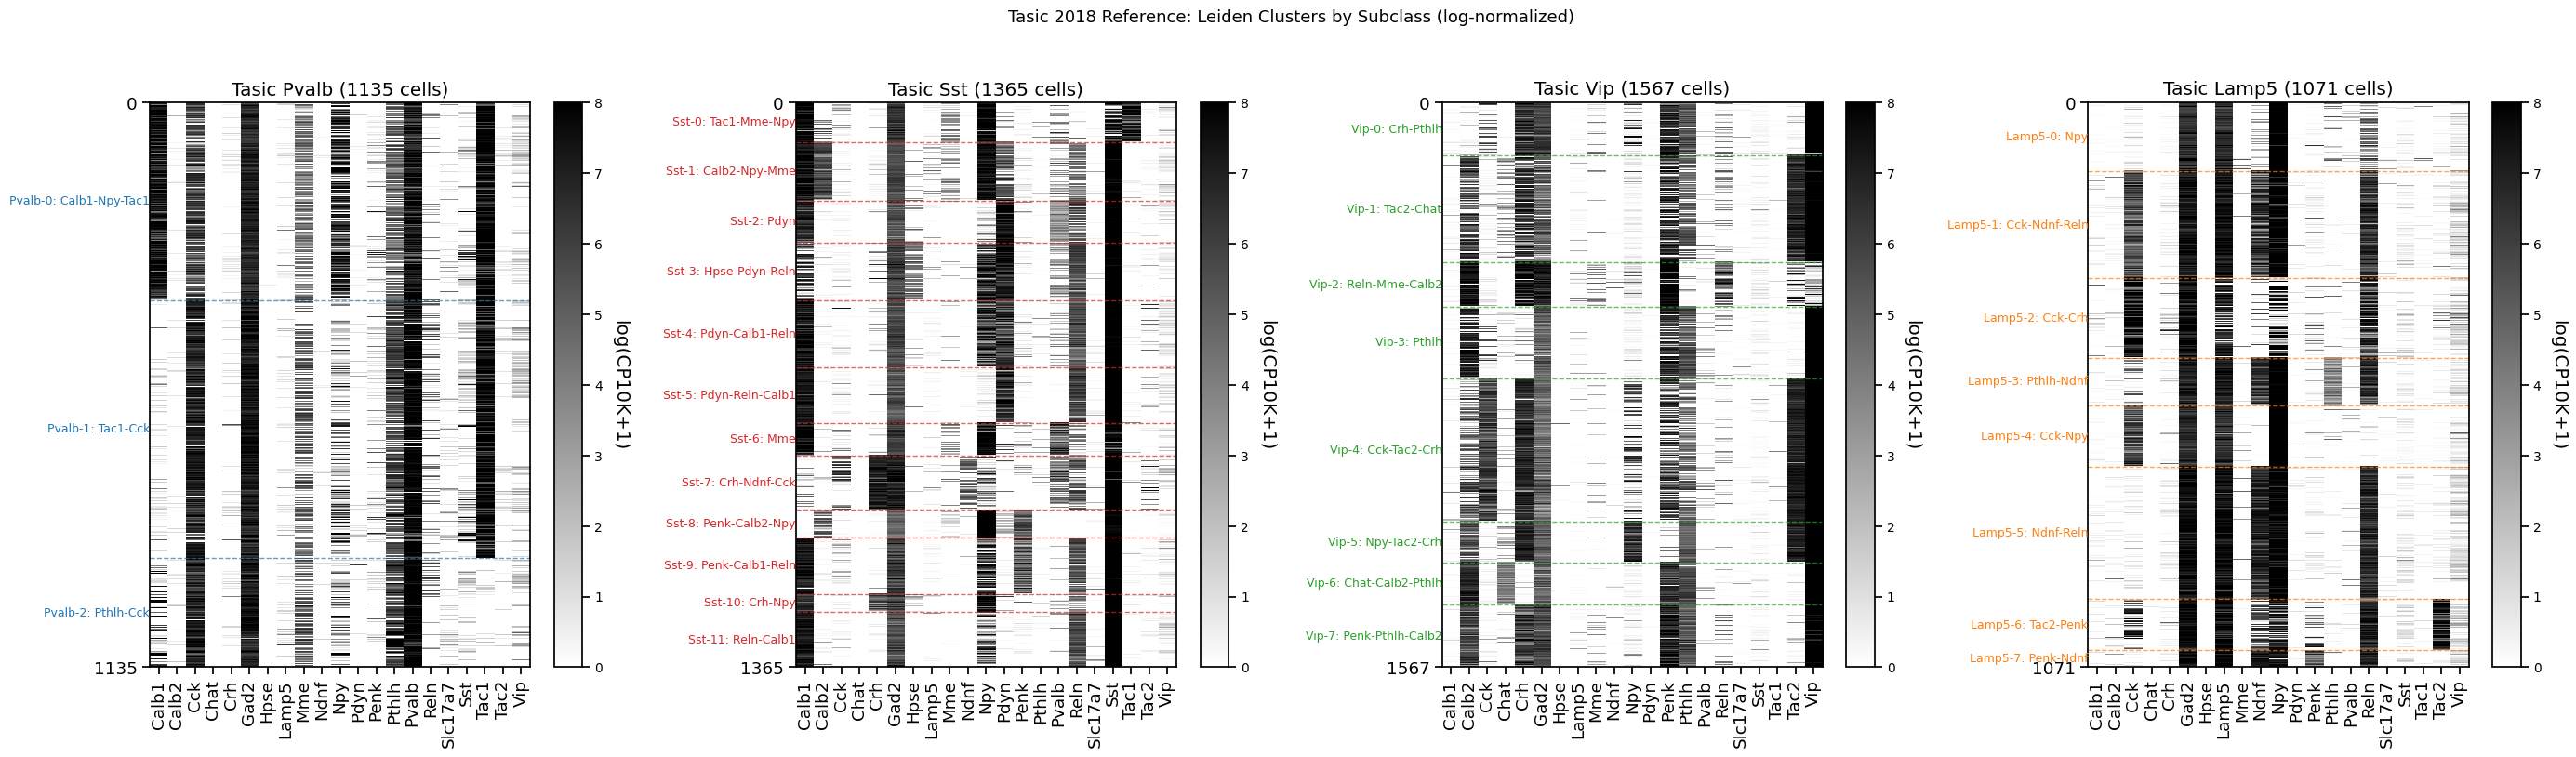

In [35]:
# Plot Tasic subclasses side by side with Leiden cluster labels (log-normalized)
TASIC_CLIP = (0, 8)  # log_cp10k scale

n_branches = len(tasic_branch_data)
fig, axes = plt.subplots(1, n_branches, figsize=(7 * n_branches, 8))
if n_branches == 1:
    axes = [axes]

for ax, (branch, (branch_cxg, branch_labels)) in zip(axes, tasic_branch_data.items()):
    viz.plot_cell_x_gene_labeled(
        branch_cxg,
        labels=branch_labels,
        clip_range=TASIC_CLIP,
        fig_size=(5, 10),
        label_fontsize=9,
        cbar_label="log(CP10K+1)",
        title=f"Tasic {branch} ({len(branch_cxg)} cells)",
        ax=ax,
        color_labels={branch: BRANCH_COLORS[branch]},
    )

plt.suptitle("Tasic 2018 Reference: Leiden Clusters by Subclass (log-normalized)", y=1.02, fontsize=13)
plt.tight_layout()

In [ ]:
# Save figure
out_path = RESULTS_DIR / f"cellxgene_raw_mouse_{MOUSE_ID}.png"
fig.savefig(out_path, dpi=150, bbox_inches="tight")
print(f"Saved: {out_path}")

# Compare HCR to Tasic

In [29]:
import seaborn as sns

Mouse 788406: 787 co-reg cell IDs loaded
Mouse 790322: 778 co-reg cell IDs loaded


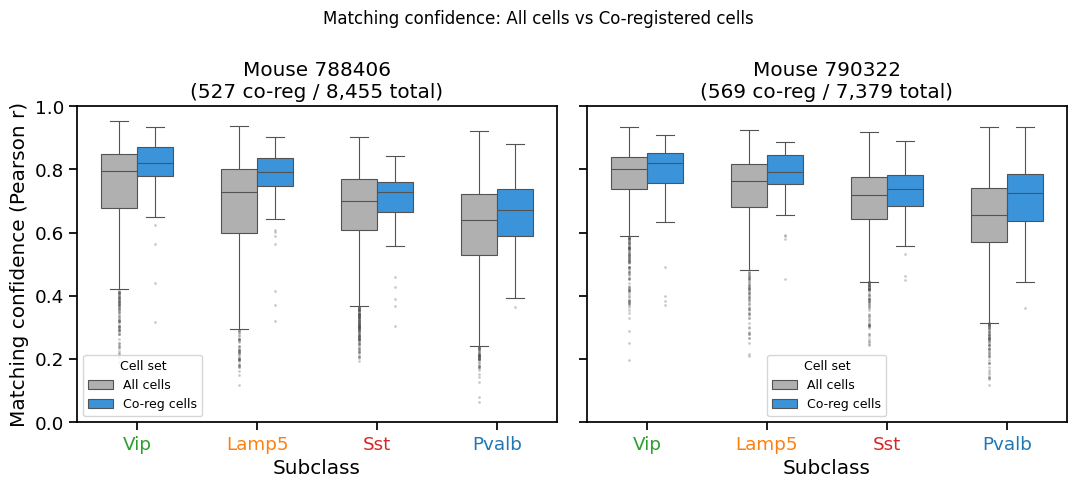

In [30]:
import sys
from pathlib import Path

# Ensure local helper module is importable from this notebook
candidate_dirs = [
    Path.cwd(),
    Path.cwd() / "code" / "cluster_validation_tasic",
    Path("/root/capsule/code/cluster_validation_tasic"),
]

for d in candidate_dirs:
    if (d / "cluster_validation_utils.py").exists():
        if str(d) not in sys.path:
            sys.path.insert(0, str(d))
        break

from cluster_validation_utils import load_coreg_cell_ids, plot_confidence_comparison
sns.set_context("notebook", font_scale=1.2)
# ── Build coreg ID sets for each mouse in the assignment table ───────────────
compare_mice = [str(m) for m in sorted(assignments["mouse_id"].unique())]

coreg_ids_by_mouse = {
    m: load_coreg_cell_ids(m, DATA_DIR) for m in compare_mice
}
for m, ids in coreg_ids_by_mouse.items():
    print(f"Mouse {m}: {len(ids):,} co-reg cell IDs loaded")

# ── Plot: All cells vs Co-reg cells, grouped by subclass ────────────────────
fig = plot_confidence_comparison(
    assignments=assignments,
    mouse_ids=compare_mice,
    coreg_ids_by_mouse=coreg_ids_by_mouse,
    branches=["Vip", "Lamp5", "Sst", "Pvalb"],
    branch_colors=BRANCH_COLORS,
)


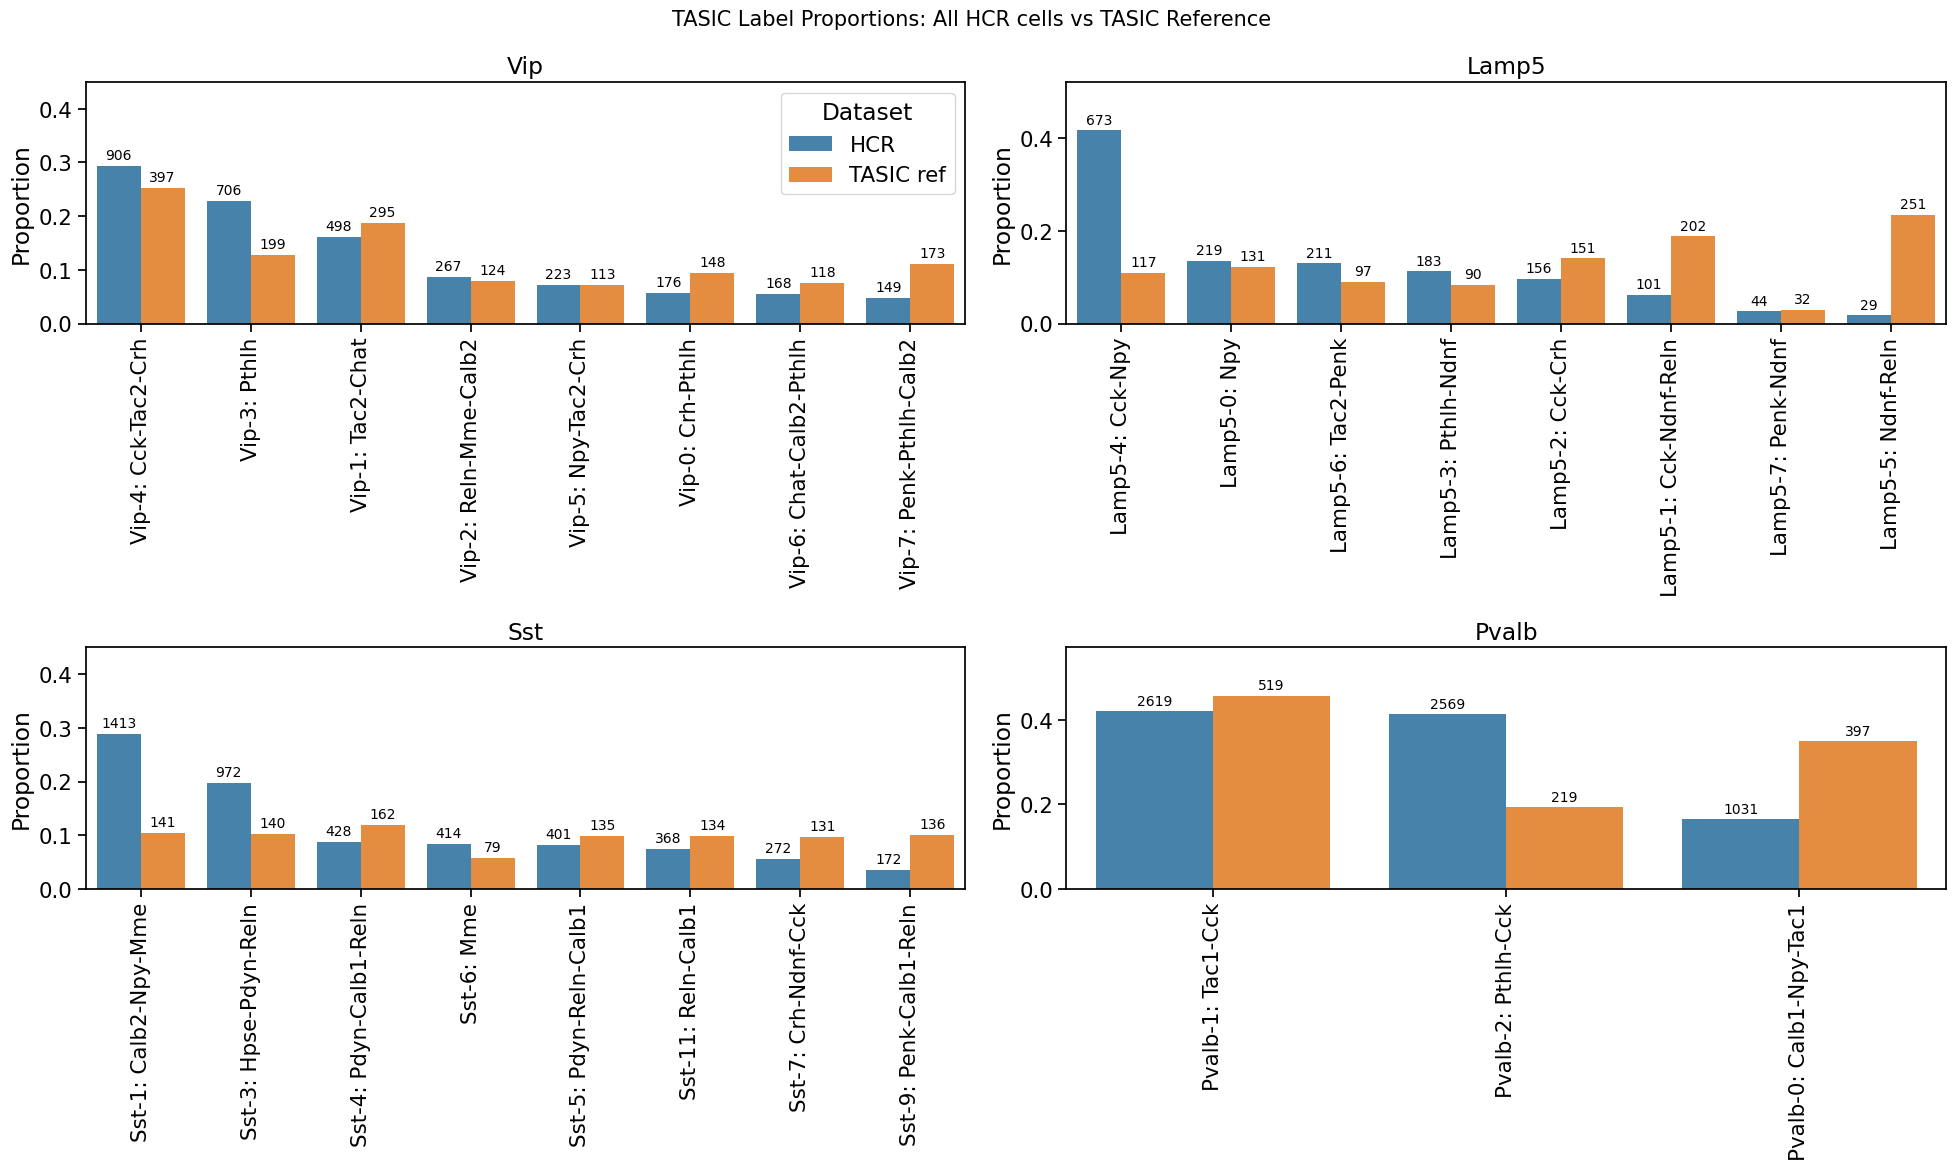

In [52]:
# TASIC label proportion comparison: HCR vs reference (4 subclass sub-panels)
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import sys
from pathlib import Path
sns.set_context("notebook", font_scale=1.4)

subclasses = ["Vip", "Lamp5", "Sst", "Pvalb"]
TOP_N = 8  # keep most represented labels per subclass for readability
USE_COREG_ONLY = False

# Ensure local helper module is importable if we need to load coreg IDs
candidate_dirs = [
    Path.cwd(),
    Path.cwd() / "code" / "cluster_validation_tasic",
    Path("/root/capsule/code/cluster_validation_tasic"),
]
for d in candidate_dirs:
    if (d / "cluster_validation_utils.py").exists():
        if str(d) not in sys.path:
            sys.path.insert(0, str(d))
        break

# Build/obtain coreg ID sets and filter HCR assignments if requested
assignments_plot = assignments.copy()
if USE_COREG_ONLY:
    if "coreg_ids_by_mouse" in globals() and isinstance(coreg_ids_by_mouse, dict):
        coreg_map = {str(k): set(v) for k, v in coreg_ids_by_mouse.items()}
    else:
        from cluster_validation_utils import load_coreg_cell_ids
        mouse_ids = sorted(assignments_plot["mouse_id"].astype(str).unique())
        coreg_map = {m: load_coreg_cell_ids(m, DATA_DIR) for m in mouse_ids}

    coreg_union = set().union(*coreg_map.values()) if coreg_map else set()
    assignments_plot = assignments_plot[
        assignments_plot["cell_id"].astype(str).isin(coreg_union)
    ].copy()

rows = []
for subclass in subclasses:
    # HCR labels for this subclass (from Stage 5 assignments)
    hcr_labels = assignments_plot.loc[
        assignments_plot["branch"].astype(str) == subclass,
        "assignment",
    ].astype(str)

    # TASIC labels for this subclass (from stage4-loaded reference branch data)
    if subclass in tasic_branch_data:
        _, tasic_labels = tasic_branch_data[subclass]
        tasic_labels = tasic_labels.astype(str)
    else:
        tasic_labels = pd.Series(dtype=str)

    hcr_counts = hcr_labels.value_counts()
    tasic_counts = tasic_labels.value_counts()
    hcr_prop = hcr_counts / max(1, hcr_counts.sum())
    tasic_prop = tasic_counts / max(1, tasic_counts.sum())

    all_labels = sorted(set(hcr_prop.index).union(set(tasic_prop.index)))
    for label in all_labels:
        rows.append({
            "subclass": subclass,
            "label": label,
            "dataset": "HCR",
            "proportion": float(hcr_prop.get(label, 0.0)),
            "count": int(hcr_counts.get(label, 0)),
        })
        rows.append({
            "subclass": subclass,
            "label": label,
            "dataset": "TASIC ref",
            "proportion": float(tasic_prop.get(label, 0.0)),
            "count": int(tasic_counts.get(label, 0)),
        })

prop_df = pd.DataFrame(rows)

fig, axes = plt.subplots(2, 2, figsize=(20, 12), sharey=False)
axes = axes.flatten()
palette = {"HCR": "#1f77b4", "TASIC ref": "#ff7f0e"}
hue_order = ["HCR", "TASIC ref"]

for i, (ax, subclass) in enumerate(zip(axes, subclasses)):
    sub = prop_df[prop_df["subclass"] == subclass].copy()
    if sub.empty:
        ax.set_title(f"{subclass} (no data)")
        ax.axis("off")
        continue

    # Drop labels absent from BOTH datasets in this subclass
    keep_nonzero = sub.groupby("label")["proportion"].sum() > 0
    keep_labels = keep_nonzero[keep_nonzero].index.tolist()
    sub = sub[sub["label"].isin(keep_labels)].copy()

    if sub.empty:
        ax.set_title(f"{subclass} (no non-zero labels)")
        ax.axis("off")
        continue

    # Keep top-N labels by max proportion across datasets
    top_labels = (
        sub.groupby("label")["proportion"]
        .max()
        .sort_values(ascending=False)
        .head(TOP_N)
        .index
        .tolist()
    )
    sub = sub[sub["label"].isin(top_labels)].copy()

    order = (
        sub[sub["dataset"] == "HCR"]
        .set_index("label")["proportion"]
        .reindex(top_labels)
        .fillna(0.0)
        .sort_values(ascending=False)
        .index
        .tolist()
    )

    sns.barplot(
        data=sub,
        x="label",
        y="proportion",
        hue="dataset",
        order=order,
        hue_order=hue_order,
        palette=palette,
        ax=ax,
        alpha=0.9,
    )

    # Annotate each bar with the correct count per dataset/category
    for container, dataset in zip(ax.containers, hue_order):
        ds_counts = (
            sub[sub["dataset"] == dataset]
            .set_index("label")["count"]
            .reindex(order)
            .fillna(0)
            .astype(int)
            .tolist()
        )
        for bar, count in zip(container, ds_counts):
            h = bar.get_height()
            x = bar.get_x() + bar.get_width() / 2
            if h > 0:
                ax.text(x, h + 0.007, f"{count}", ha="center", va="bottom", fontsize=10)

    ax.set_title(subclass)
    ax.set_xlabel("")
    ax.set_ylabel("Proportion")
    ax.set_ylim(0, max(0.45, sub["proportion"].max() * 1.25))
    ax.tick_params(axis="x", rotation=90)

    if i == 0:
        ax.legend(title="Dataset")
    else:
        legend = ax.get_legend()
        if legend is not None:
            legend.remove()

mode_txt = "Co-registered HCR cells only" if USE_COREG_ONLY else "All HCR cells"
fig.suptitle(f"TASIC Label Proportions: {mode_txt} vs TASIC Reference", fontsize=15)
plt.tight_layout()


# Plot locations

/src/aind-hcr-data-loader/src/aind_hcr_data_loader/hcr_dataset.py:464: UserWarning: Getting cell info from cell x gene file. Does not include all segmentation masks; but this is usually fine.
  warnings.warn(


Merged 8,451 cells; confidence range 0.117–0.952


,cell_id_x,volume,x_centroid,y_centroid,z_centroid,cell_id_numeric,cell_id_y,confidence
0,234,511472.0,1568,1102,96,234,788406_234,0.611699
1,302,333472.0,208,5070,95,302,788406_302,0.407605
2,550,890592.0,596,4118,104,550,788406_550,0.411561
3,736,382864.0,762,3076,105,736,788406_736,0.669228
4,1162,619552.0,2276,8810,124,1162,788406_1162,0.552859


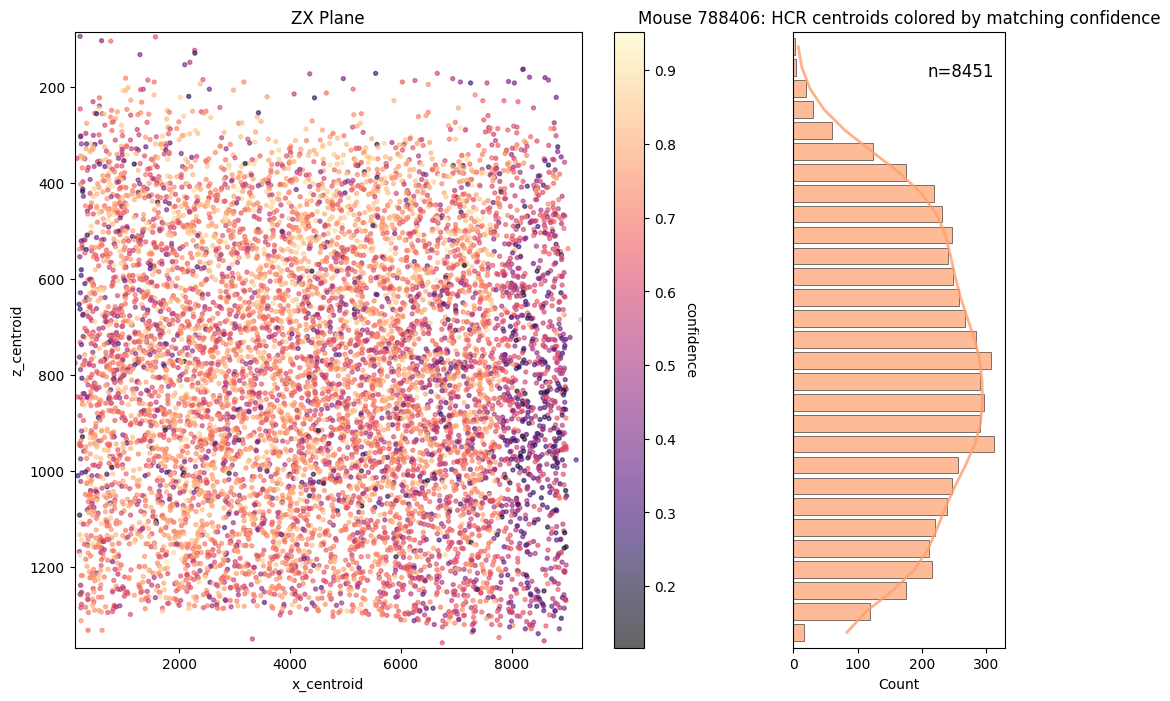

In [35]:
from aind_hcr_qc.viz.cell_x_gene import plot_centroids_with_hist


def plot_hcr_centroids_by_confidence(
    dataset,
    confidence_df,
    round_key="R1",
    source="mixed_cxg",
    cell_id_col="cell_id",
    confidence_col="confidence",
    orientation="XY",
    cmap="viridis",
    clip_range=None,
    title=None,
    n_samples=None,
):
    """
    Load HCR cell centroids, merge with per-cell confidence, and plot them.

    Parameters
    ----------
    dataset : HCRDataset
        HCR dataset object.
    confidence_df : pd.DataFrame
        Table containing per-cell confidence values.
    round_key : str
        Round from which to load cell centroids.
    source : str
        Source passed to get_cell_info. Use "mixed_cxg" for cells with spots or
        "segmentation" for all segmented cells.
    cell_id_col : str
        Column in confidence_df containing cell ids.
    confidence_col : str
        Column in confidence_df containing confidence values.
    orientation : str
        One of "XY", "ZX", or "ZY".
    cmap : str
        Matplotlib colormap name.
    clip_range : tuple[float, float] | None
        Optional clipping range for confidence coloring.
    title : str | None
        Optional panel title.
    n_samples : int | None
        Optional random subsample size for plotting.

    Returns
    -------
    fig : matplotlib.figure.Figure
    centroid_conf_df : pd.DataFrame
        Merged centroid + confidence table used for plotting.
    """
    centroid_conf_df = dataset.rounds[round_key].get_cell_info(source=source, verbose=False).copy()

    conf = confidence_df.copy()
    if cell_id_col not in conf.columns:
        if conf.index.name == cell_id_col:
            conf = conf.reset_index()
        else:
            raise ValueError(f"'{cell_id_col}' not found in confidence_df columns or index.")

    if confidence_col not in conf.columns:
        raise ValueError(f"'{confidence_col}' not found in confidence_df.")

    conf["cell_id_numeric"] = pd.to_numeric(
        conf[cell_id_col].astype(str).str.rsplit("_", n=1).str[-1],
        errors="coerce",
    )
    centroid_conf_df["cell_id_numeric"] = pd.to_numeric(
        centroid_conf_df["cell_id"],
        errors="coerce",
    )

    conf = conf.dropna(subset=["cell_id_numeric", confidence_col]).copy()
    conf = conf.drop_duplicates(subset=["cell_id_numeric"])

    centroid_conf_df = centroid_conf_df.merge(
        conf[[cell_id_col, "cell_id_numeric", confidence_col]],
        on="cell_id_numeric",
        how="inner",
        validate="1:1",
    )

    if centroid_conf_df.empty:
        raise ValueError("No overlapping cells found between HCR centroids and confidence table.")

    if clip_range is None:
        clip_range = (
            float(centroid_conf_df[confidence_col].min()),
            float(centroid_conf_df[confidence_col].max()),
        )

    fig = plot_centroids_with_hist(
        centroid_conf_df,
        orientation=orientation,
        n_samples=n_samples,
        color_col=confidence_col,
        cmap=cmap,
        clip_range=clip_range,
        title_str=title or f"{round_key} centroids colored by {confidence_col}",
        show_colorbar=True,
    )

    return fig, centroid_conf_df


fig, centroid_conf_df = plot_hcr_centroids_by_confidence(
    ds,
    mouse_assignments,
    round_key="R1",
    source="mixed_cxg",
    orientation="ZX",
    cmap="magma",
    title=f"Mouse {MOUSE_ID}: HCR centroids colored by matching confidence",
)

print(
    f"Merged {len(centroid_conf_df):,} cells; confidence range "
    f"{centroid_conf_df['confidence'].min():.3f}–{centroid_conf_df['confidence'].max():.3f}"
)
centroid_conf_df.head()


## plot centroid locations of tasic cluster

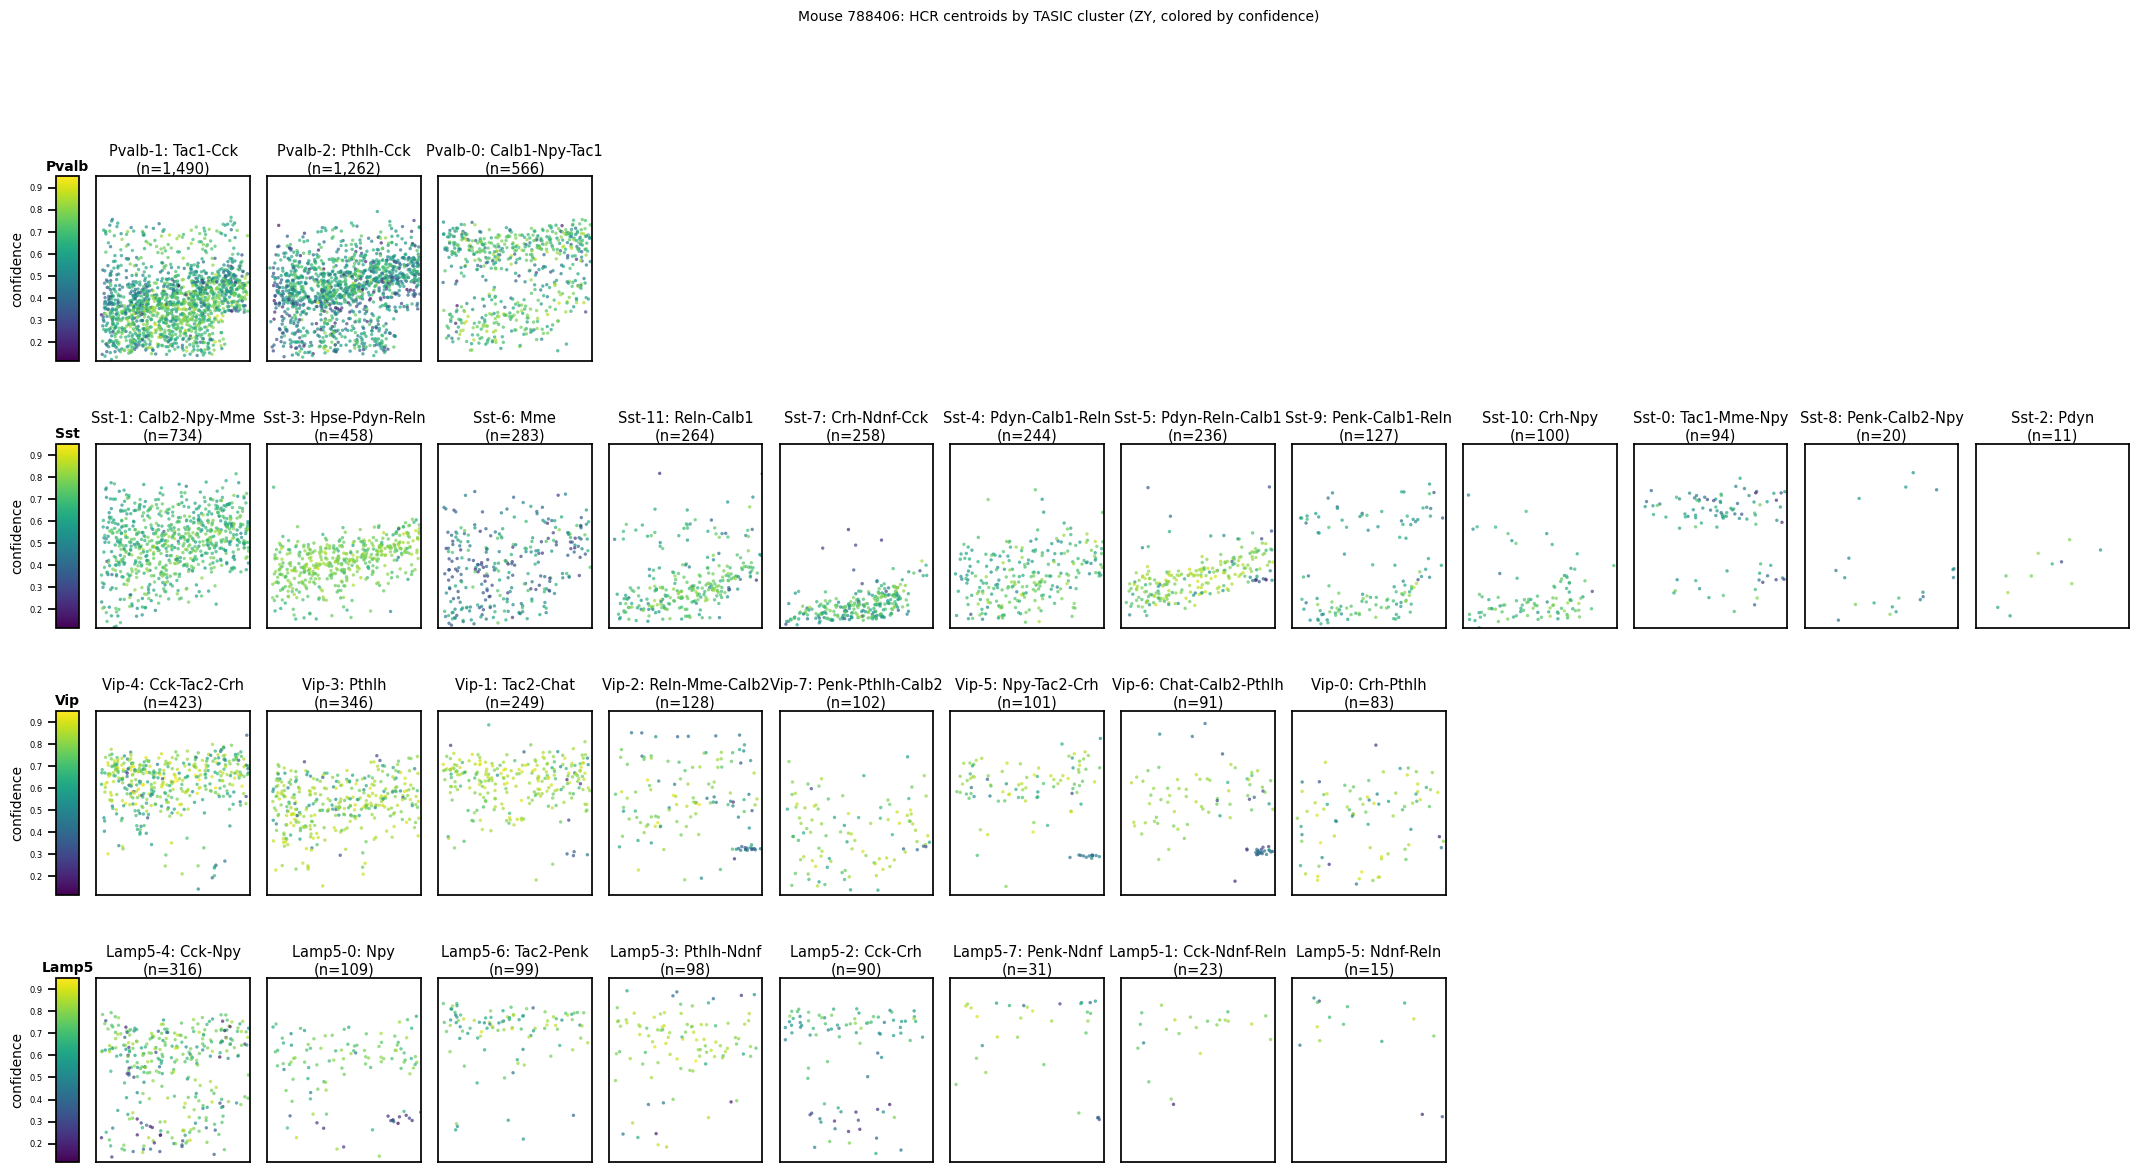

In [46]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib

sns.set_context("notebook", font_scale=1.4)
# ---- plotting flags ----
ORIENTATION = "ZY"  # one of: "XY", "ZX", "ZY"
CMAP = "viridis"
POINT_SIZE = 6
POINT_ALPHA = 0.7

# Build working table: centroids + assignment + branch + confidence
plot_data = centroid_conf_df.merge(
    mouse_assignments[["cell_id", "assignment", "branch"]],
    left_on="cell_id_y",
    right_on="cell_id",
    how="inner",
)

conf_vmin = plot_data["confidence"].min()
conf_vmax = plot_data["confidence"].max()

# Orientation mapping (same style as centroid helpers)
ORIENT_MAP = {
    "XY": ("x_centroid", "y_centroid", "x centroid", "y centroid"),
    "ZX": ("x_centroid", "z_centroid", "x centroid", "z centroid"),
    "ZY": ("y_centroid", "z_centroid", "y centroid", "z centroid"),
}
if ORIENTATION not in ORIENT_MAP:
    raise ValueError(f"ORIENTATION must be one of {list(ORIENT_MAP.keys())}")

x_col, y_col, x_label, y_label = ORIENT_MAP[ORIENTATION]
max_x = plot_data[x_col].max()
max_y = plot_data[y_col].max()

subclasses = [b for b in ["Pvalb", "Sst", "Vip", "Lamp5"] if b in plot_data["branch"].values]

# Order clusters within each subclass by descending cell count
subclass_clusters = {}
for b in subclasses:
    sub_b = plot_data[plot_data["branch"] == b]
    cluster_order = sub_b["assignment"].value_counts().sort_values(ascending=False).index.tolist()
    subclass_clusters[b] = cluster_order

max_cols = max(len(v) for v in subclass_clusters.values())
n_rows = len(subclasses)

# Shared ScalarMappable — drives every colorbar without touching any scatter ax
norm = plt.Normalize(vmin=conf_vmin, vmax=conf_vmax)
sm = plt.cm.ScalarMappable(cmap=CMAP, norm=norm)
sm.set_array([])

# GridSpec: column 0 is a narrow dedicated colorbar column; the rest are equal scatter columns
fig = plt.figure(figsize=(0.35 + max_cols * 2.2, n_rows * 3.2))
gs = gridspec.GridSpec(
    n_rows, max_cols + 1,
    width_ratios=[0.15] + [1.0] * max_cols,
    hspace=0.45,
    wspace=0.12,
)

for row_i, subclass in enumerate(subclasses):
    clusters = subclass_clusters[subclass]
    sub_all = plot_data[plot_data["branch"] == subclass]

    # Dedicated colorbar axis — column 0
    cbar_ax = fig.add_subplot(gs[row_i, 0])
    cbar = fig.colorbar(sm, cax=cbar_ax)
    cbar.set_label("confidence", fontsize=10, labelpad=4)
    cbar.ax.tick_params(labelsize=6)
    cbar.ax.yaxis.set_label_position("left")
    cbar.ax.yaxis.tick_left()
    # Subclass row label above the colorbar
    cbar_ax.set_title(subclass, fontsize=10, fontweight="bold", pad=4)

    # Scatter panels — columns 1..max_cols
    for col_i in range(max_cols):
        ax = fig.add_subplot(gs[row_i, col_i + 1])

        if col_i >= len(clusters):
            ax.set_visible(False)
            continue

        cluster = clusters[col_i]
        sub = sub_all[sub_all["assignment"] == cluster]

        ax.scatter(
            sub[x_col], sub[y_col],
            c=sub["confidence"], cmap=CMAP,
            vmin=conf_vmin, vmax=conf_vmax,
            s=POINT_SIZE, alpha=POINT_ALPHA, linewidths=0,
        )

        ax.set_xlim(0, max_x)
        ax.set_ylim(0, max_y)
        ax.invert_yaxis()
        ax.set_title(f"{cluster}\n(n={len(sub):,})", fontsize=10.5, pad=2)
        ax.set_xticks([])
        ax.set_yticks([])

fig.suptitle(
    f"Mouse {MOUSE_ID}: HCR centroids by TASIC cluster ({ORIENTATION}, colored by confidence)",
    fontsize=10, y=1.01,
)
plt.show()

/tmp/ipykernel_7247/3725498327.py:22: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


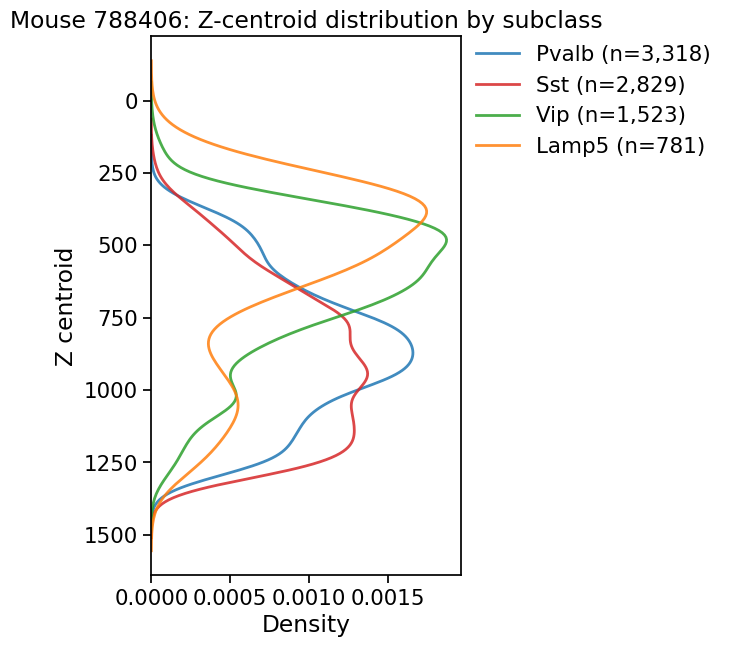

In [54]:
fig, ax = plt.subplots(figsize=(4, 7))

for subclass in ["Pvalb", "Sst", "Vip", "Lamp5"]:
    sub = plot_data[plot_data["branch"] == subclass]["z_centroid"].dropna()
    if sub.empty:
        continue
    sns.kdeplot(
        y=sub,
        ax=ax,
        label=f"{subclass} (n={len(sub):,})",
        color=BRANCH_COLORS.get(subclass, None),
        linewidth=2,
        fill=False,
        alpha=0.85,
    )

ax.invert_yaxis()
ax.set_ylabel("Z centroid")
ax.set_xlabel("Density")
ax.set_title(f"Mouse {MOUSE_ID}: Z-centroid distribution by subclass")
ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1.0), borderaxespad=0.0, frameon=False)
plt.tight_layout()
plt.show()

# cluster centroid

## Confidence vs Z Depth

Check whether matching confidence changes with z-centroid depth using a regression-style scatter plot and depth-binned summary.

      metric         value
   pearson_r -9.906424e-02
   pearson_p  3.342620e-17
spearman_rho -9.530263e-02
  spearman_p  4.971860e-16
       slope -3.643284e-05
   r_squared  9.813723e-03
     n_cells  7.215000e+03


,z_median,z_min,z_max,confidence_mean,confidence_median,n
0,439.0,184,495,0.730272,0.744041,610
1,542.0,496,581,0.730853,0.735153,598
2,626.0,582,672,0.728676,0.730843,599
3,711.0,673,750,0.711459,0.717521,601
4,790.0,751,824,0.700551,0.705293,607
5,859.0,825,889,0.699393,0.705569,598
6,925.0,890,957,0.705979,0.718364,604
7,993.0,958,1025,0.706033,0.712820,594
8,1060.5,1026,1102,0.713461,0.728278,602
9,1148.0,1103,1194,0.718477,0.729701,605


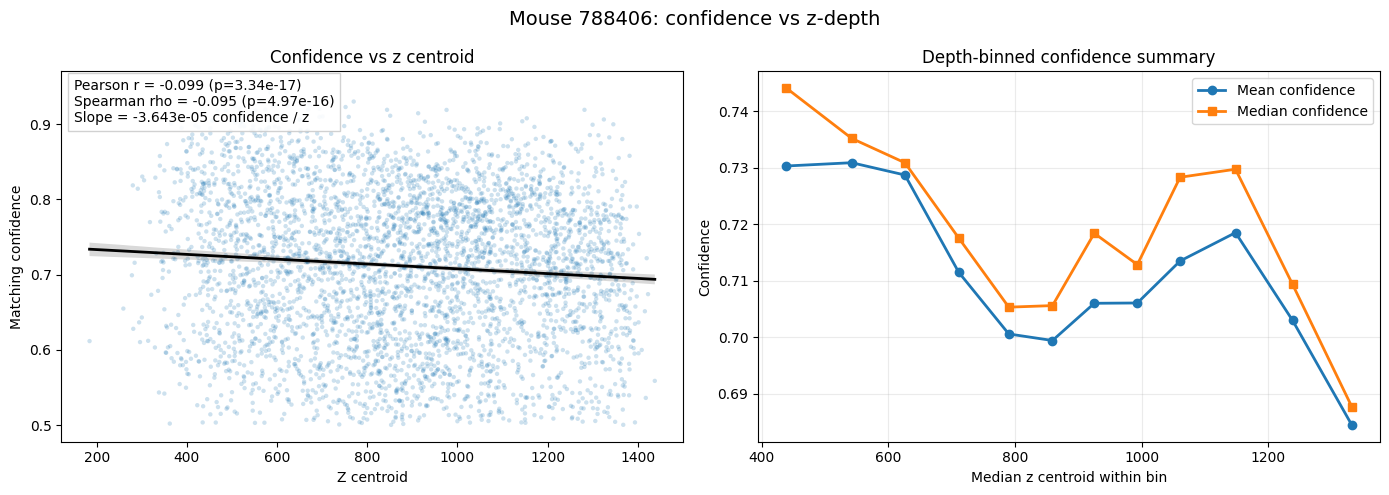

In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import linregress, pearsonr, spearmanr


def plot_confidence_vs_z_depth(
    centroid_conf_df,
    z_col="z_centroid",
    confidence_col="confidence",
    n_bins=12,
    sample_n=4000,
    random_state=42,
):
    """Plot and summarize the relationship between confidence and z depth."""
    plot_df = centroid_conf_df[[z_col, confidence_col]].dropna().copy()
    if plot_df.empty:
        raise ValueError("No non-null z/confidence rows available.")

    plot_df[z_col] = pd.to_numeric(plot_df[z_col], errors="coerce")
    plot_df[confidence_col] = pd.to_numeric(plot_df[confidence_col], errors="coerce")
    plot_df = plot_df.dropna().copy()
    if len(plot_df) < 3:
        raise ValueError("Need at least 3 rows to fit a depth-confidence relationship.")

    pearson_r, pearson_p = pearsonr(plot_df[z_col], plot_df[confidence_col])
    spearman_rho, spearman_p = spearmanr(plot_df[z_col], plot_df[confidence_col])
    fit = linregress(plot_df[z_col], plot_df[confidence_col])

    if sample_n is not None and len(plot_df) > sample_n:
        scatter_df = plot_df.sample(sample_n, random_state=random_state)
    else:
        scatter_df = plot_df

    depth_bins = pd.qcut(plot_df[z_col], q=n_bins, duplicates="drop")
    depth_summary = (
        plot_df.assign(depth_bin=depth_bins)
        .groupby("depth_bin", observed=False)
        .agg(
            z_median=(z_col, "median"),
            z_min=(z_col, "min"),
            z_max=(z_col, "max"),
            confidence_mean=(confidence_col, "mean"),
            confidence_median=(confidence_col, "median"),
            n=(confidence_col, "size"),
        )
        .reset_index(drop=True)
    )

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    sns.regplot(
        data=scatter_df,
        x=z_col,
        y=confidence_col,
        scatter_kws={"s": 10, "alpha": 0.22, "edgecolor": "none"},
        line_kws={"color": "black", "linewidth": 2},
        ax=axes[0],
    )
    axes[0].set_title("Confidence vs z centroid")
    axes[0].set_xlabel("Z centroid")
    axes[0].set_ylabel("Matching confidence")
    axes[0].text(
        0.02,
        0.98,
        (
            f"Pearson r = {pearson_r:.3f} (p={pearson_p:.2e})\n"
            f"Spearman rho = {spearman_rho:.3f} (p={spearman_p:.2e})\n"
            f"Slope = {fit.slope:.4g} confidence / z"
        ),
        transform=axes[0].transAxes,
        va="top",
        ha="left",
        bbox={"facecolor": "white", "alpha": 0.9, "edgecolor": "0.8"},
    )

    axes[1].plot(
        depth_summary["z_median"],
        depth_summary["confidence_mean"],
        marker="o",
        linewidth=2,
        label="Mean confidence",
    )
    axes[1].plot(
        depth_summary["z_median"],
        depth_summary["confidence_median"],
        marker="s",
        linewidth=2,
        label="Median confidence",
    )
    axes[1].set_title("Depth-binned confidence summary")
    axes[1].set_xlabel("Median z centroid within bin")
    axes[1].set_ylabel("Confidence")
    axes[1].legend()
    axes[1].grid(alpha=0.25)

    fig.suptitle(f"Mouse {MOUSE_ID}: confidence vs z-depth", fontsize=14)
    plt.tight_layout()

    stats_df = pd.DataFrame(
        {
            "metric": ["pearson_r", "pearson_p", "spearman_rho", "spearman_p", "slope", "r_squared", "n_cells"],
            "value": [
                pearson_r,
                pearson_p,
                spearman_rho,
                spearman_p,
                fit.slope,
                fit.rvalue ** 2,
                float(len(plot_df)),
            ],
        }
    )

    return fig, stats_df, depth_summary


fig_depth, depth_stats_df, depth_summary_df = plot_confidence_vs_z_depth(centroid_conf_df)
print(depth_stats_df.to_string(index=False))
depth_summary_df

## Low-R² Gene Diagnostics (Read-Only Stage 5 Summary)

This section summarizes why `Pthlh`, `Ndnf`, `Chat`, and `Slc17a7` are low-R² across mice using existing stage5 outputs only.

It reports:
- Per-mouse rank and instability for each target gene
- Cross-mouse averaged summary
- Cluster-level hotspots from `mean_expression_diff.csv`
- Confidence vs residual-cell-norm relationship (cell-level fit proxy)

In [54]:
import pandas as pd
import numpy as np
from pathlib import Path

stage5_dir = Path('/root/capsule/scratch/hcr_tasic_matching/stage5')
target_genes = ['Pthlh', 'Ndnf', 'Chat', 'Slc17a7']

rows = []
for mouse_dir in sorted(stage5_dir.glob('mouse_*')):
    mouse = mouse_dir.name.replace('mouse_', '')

    r2_path = mouse_dir / 'clustering_r2_per_gene.csv'
    inst_path = mouse_dir / 'residual_gene_instability.csv'
    diff_path = mouse_dir / 'mean_expression_diff.csv'

    if not (r2_path.exists() and inst_path.exists() and diff_path.exists()):
        continue

    r2_df = pd.read_csv(r2_path)
    gene_col = 'gene' if 'gene' in r2_df.columns else [c for c in r2_df.columns if 'gene' in c.lower()][0]
    r2_col = 'r2' if 'r2' in r2_df.columns else [c for c in r2_df.columns if 'r2' in c.lower()][0]
    r2_df = r2_df.sort_values(r2_col).reset_index(drop=True)

    inst_df = pd.read_csv(inst_path)
    inst_gene_col = 'gene' if 'gene' in inst_df.columns else [c for c in inst_df.columns if 'gene' in c.lower()][0]
    inst_col = [c for c in inst_df.columns if c != inst_gene_col][0]
    inst_df = inst_df.sort_values(inst_col, ascending=False).reset_index(drop=True)

    diff_df = pd.read_csv(diff_path)
    if '_label' not in diff_df.columns:
        continue

    for g in target_genes:
        if g not in r2_df[gene_col].values or g not in inst_df[inst_gene_col].values or g not in diff_df.columns:
            continue

        r2_val = float(r2_df.loc[r2_df[gene_col] == g, r2_col].iloc[0])
        r2_rank = int(np.where(r2_df[gene_col].values == g)[0][0] + 1)

        inst_val = float(inst_df.loc[inst_df[inst_gene_col] == g, inst_col].iloc[0])
        inst_rank = int(np.where(inst_df[inst_gene_col].values == g)[0][0] + 1)

        abs_diff = diff_df[g].astype(float).abs().values
        if abs_diff.sum() == 0:
            conc_top1 = 0.0
            conc_top3 = 0.0
        else:
            s = np.sort(abs_diff)[::-1]
            conc_top1 = float(s[:1].sum() / s.sum())
            conc_top3 = float(s[:3].sum() / s.sum())

        top_idx = int(np.argmax(abs_diff))
        top_cluster = str(diff_df['_label'].iloc[top_idx])
        top_abs = float(abs_diff[top_idx])

        rows.append({
            'mouse': mouse,
            'gene': g,
            'r2': r2_val,
            'r2_rank_low_is_worse': r2_rank,
            'instability': inst_val,
            'instability_rank_high_is_worse': inst_rank,
            'concentration_top1': conc_top1,
            'concentration_top3': conc_top3,
            'top_mismatch_cluster': top_cluster,
            'top_abs_mean_diff': top_abs,
        })

diagnostics_df = pd.DataFrame(rows)
print('Per-mouse diagnostics for low-R² genes')
print(diagnostics_df.sort_values(['mouse', 'r2_rank_low_is_worse']).to_string(index=False))

print('\nCross-mouse summary (mean across mice)')
if diagnostics_df.empty:
    print('No diagnostics rows found.')
else:
    summary_df = (
        diagnostics_df
        .groupby('gene', as_index=False)
        .agg({
            'r2': 'mean',
            'r2_rank_low_is_worse': 'mean',
            'instability': 'mean',
            'instability_rank_high_is_worse': 'mean',
            'concentration_top1': 'mean',
            'concentration_top3': 'mean',
            'top_abs_mean_diff': 'mean',
        })
        .sort_values('r2_rank_low_is_worse')
    )
    print(summary_df.to_string(index=False))

print('\nConfidence vs residual cell norm (cell-level, not gene-specific)')
assign_path = stage5_dir / 'hcr_assignments_leiden_named.csv'
if assign_path.exists():
    assignments_all = pd.read_csv(assign_path)

    for mouse_dir in sorted(stage5_dir.glob('mouse_*')):
        mouse = mouse_dir.name.replace('mouse_', '')
        residual_path = mouse_dir / 'residual_cell_norms.csv'
        if not residual_path.exists():
            continue

        assign_sub = assignments_all[assignments_all['mouse_id'].astype(str) == mouse][['cell_id', 'confidence']].copy()
        residual_df = pd.read_csv(residual_path)

        cell_col = 'cell_id' if 'cell_id' in residual_df.columns else residual_df.columns[0]
        norm_candidates = [c for c in residual_df.columns if 'norm' in c.lower() or 'resid' in c.lower()]
        if not norm_candidates:
            print(f'mouse {mouse}: no residual norm-like column found')
            continue
        norm_col = norm_candidates[0]

        joined = assign_sub.merge(
            residual_df[[cell_col, norm_col]].rename(columns={cell_col: 'cell_id'}),
            on='cell_id',
            how='inner',
        ).dropna()

        if len(joined) < 20:
            print(f'mouse {mouse}: insufficient joined rows ({len(joined)})')
            continue

        joined = joined.sort_values('confidence').reset_index(drop=True)
        q = max(1, len(joined) // 10)
        low_med = float(joined.iloc[:q][norm_col].median())
        high_med = float(joined.iloc[-q:][norm_col].median())
        ratio = high_med / low_med if low_med != 0 else np.nan

        print(
            f"mouse {mouse}: n={len(joined)}, "
            f"median_resid_low_conf={low_med:.4f}, "
            f"median_resid_high_conf={high_med:.4f}, "
            f"high/low={ratio:.3f}"
        )

Per-mouse diagnostics for low-R² genes
 mouse    gene       r2  r2_rank_low_is_worse  instability  instability_rank_high_is_worse  concentration_top1  concentration_top3    top_mismatch_cluster  top_abs_mean_diff
788406 Slc17a7 0.120017                     1     1.013777                               1            0.117555            0.281814      Lamp5-5: Ndnf-Reln           1.243028
788406    Chat 0.243998                     2     0.899759                               4            0.180097            0.297260 Vip-6: Chat-Calb2-Pthlh           3.133136
788406    Ndnf 0.265032                     3     0.903130                               3            0.087637            0.236233      Lamp5-5: Ndnf-Reln           1.397063
788406   Pthlh 0.272972                     4     0.815185                               5            0.062191            0.176935   Sst-3: Hpse-Pdyn-Reln           1.106786
790322 Slc17a7 0.137907                     1     0.926647                               1 

## Low-R² Gene Issue Plots

Visual summary to highlight the main failure modes for `Pthlh`, `Ndnf`, `Chat`, and `Slc17a7`:
- Cross-mouse mean `R²` and instability ranks
- Gene-by-mouse `R²` heatmap
- Largest cluster mismatch per gene
- Confidence impact on residual norm

/tmp/ipykernel_59889/1049536374.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=summary_plot_df, x='gene', y='r2_mean', ax=axes[0], palette='viridis_r')
/tmp/ipykernel_59889/1049536374.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=summary_plot_df, x='gene', y='instability_mean', ax=axes[1], palette='magma')
/tmp/ipykernel_59889/1049536374.py:71: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=hotspot_df, x='gene', y='top_abs_mean_diff', ax=axes[1], palette='rocket')



Top mismatch cluster by gene and mouse:
 mouse    gene    top_mismatch_cluster  top_abs_mean_diff
788406    Chat Vip-6: Chat-Calb2-Pthlh           3.133136
790322    Chat Vip-6: Chat-Calb2-Pthlh           2.762040
788406    Ndnf      Lamp5-5: Ndnf-Reln           1.397063
790322    Ndnf   Sst-8: Penk-Calb2-Npy           0.992058
788406   Pthlh   Sst-3: Hpse-Pdyn-Reln           1.106786
790322   Pthlh   Sst-8: Penk-Calb2-Npy           0.915738
788406 Slc17a7      Lamp5-5: Ndnf-Reln           1.243028
790322 Slc17a7   Sst-8: Penk-Calb2-Npy           0.703703


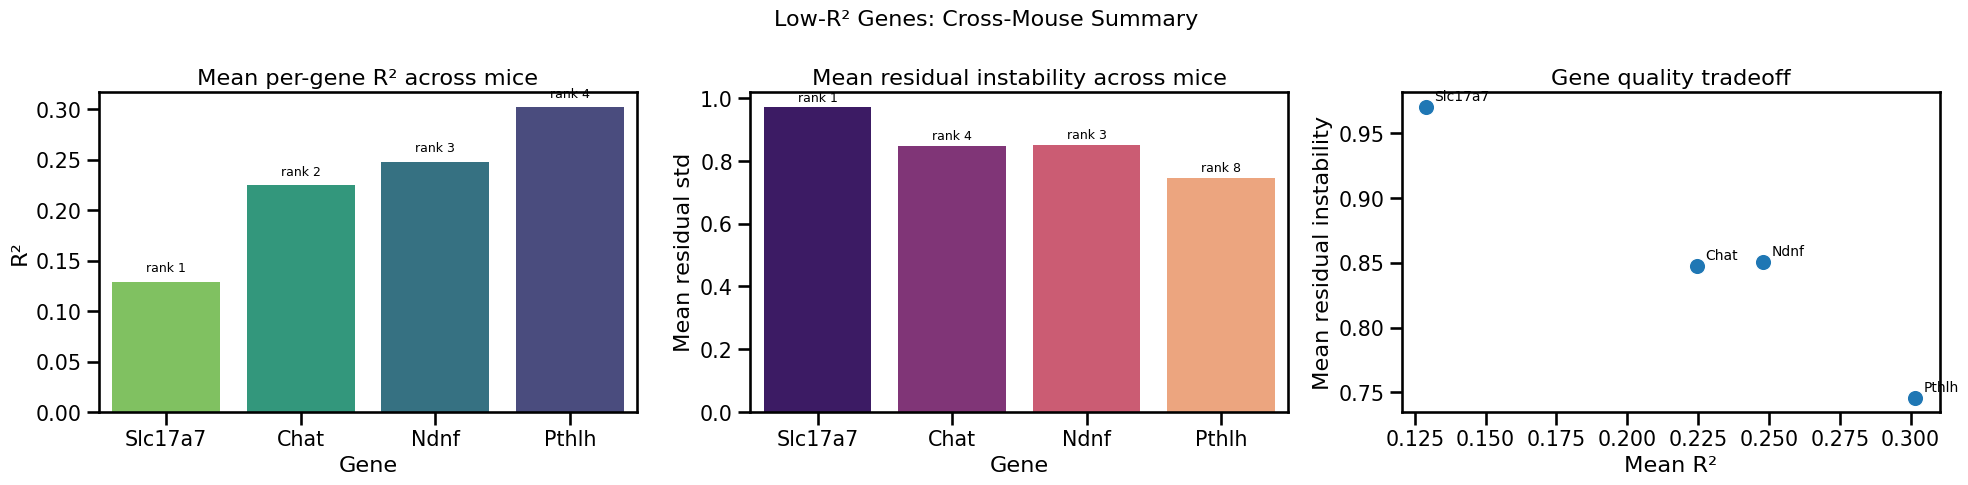

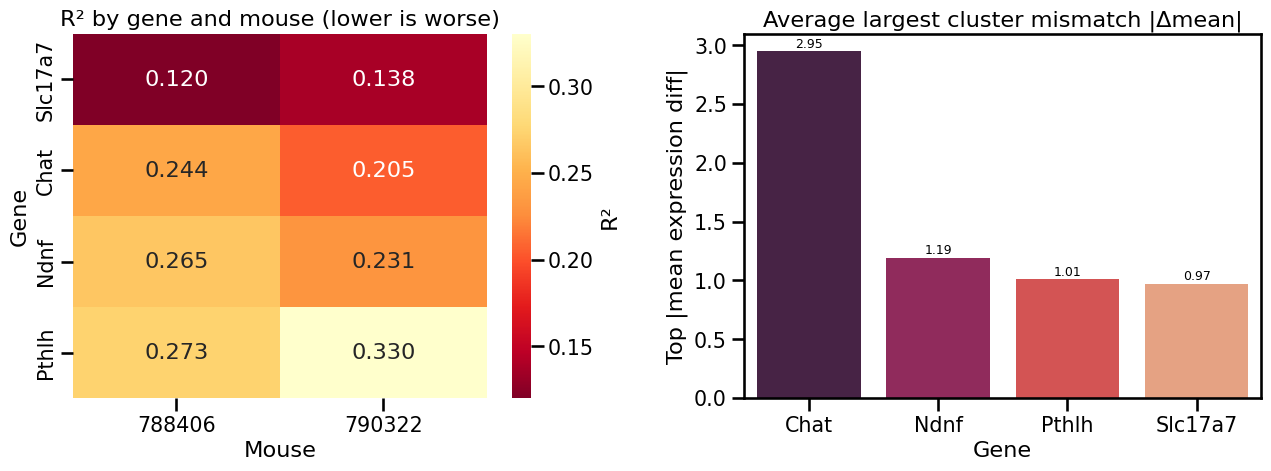

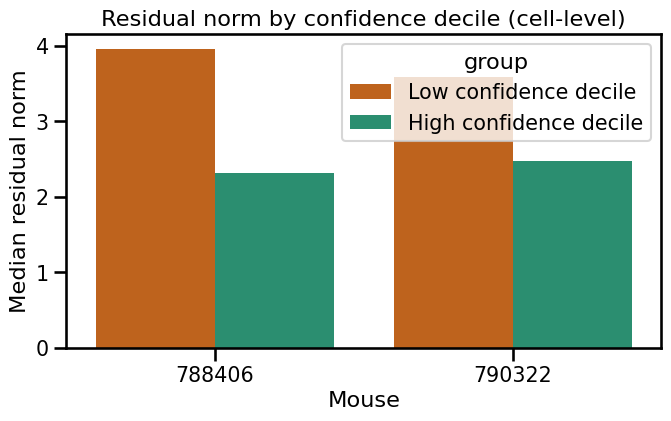

In [56]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

sns.set_context("talk", font_scale=0.9)

if 'diagnostics_df' not in globals() or diagnostics_df.empty:
    raise ValueError("Run Cell 20 (Low-R² Gene Diagnostics) first to populate diagnostics_df.")

# --- Figure 1: Cross-mouse summary bars + scatter ---
summary_plot_df = (
    diagnostics_df
    .groupby('gene', as_index=False)
    .agg(
        r2_mean=('r2', 'mean'),
        instability_mean=('instability', 'mean'),
        r2_rank_mean=('r2_rank_low_is_worse', 'mean'),
        instability_rank_mean=('instability_rank_high_is_worse', 'mean'),
        top_abs_diff_mean=('top_abs_mean_diff', 'mean'),
    )
    .sort_values('r2_rank_mean')
)

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# A) Mean R2 (lower is worse)
sns.barplot(data=summary_plot_df, x='gene', y='r2_mean', ax=axes[0], palette='viridis_r')
axes[0].set_title('Mean per-gene R² across mice')
axes[0].set_xlabel('Gene')
axes[0].set_ylabel('R²')
for i, r in summary_plot_df.reset_index(drop=True).iterrows():
    axes[0].text(i, r['r2_mean'] + 0.01, f"rank {int(r['r2_rank_mean'])}", ha='center', fontsize=9)

# B) Mean instability (higher is worse)
sns.barplot(data=summary_plot_df, x='gene', y='instability_mean', ax=axes[1], palette='magma')
axes[1].set_title('Mean residual instability across mice')
axes[1].set_xlabel('Gene')
axes[1].set_ylabel('Mean residual std')
for i, r in summary_plot_df.reset_index(drop=True).iterrows():
    axes[1].text(i, r['instability_mean'] + 0.02, f"rank {int(round(r['instability_rank_mean']))}", ha='center', fontsize=9)

# C) R2 vs instability relationship
sns.scatterplot(data=summary_plot_df, x='r2_mean', y='instability_mean', s=140, ax=axes[2])
for _, r in summary_plot_df.iterrows():
    axes[2].text(r['r2_mean'] + 0.003, r['instability_mean'] + 0.005, r['gene'], fontsize=10)
axes[2].set_title('Gene quality tradeoff')
axes[2].set_xlabel('Mean R²')
axes[2].set_ylabel('Mean residual instability')

fig.suptitle('Low-R² Genes: Cross-Mouse Summary', fontsize=16)
plt.tight_layout()

# --- Figure 2: Gene-by-mouse heatmap of R2 and top mismatch magnitude ---
heat_df = diagnostics_df.pivot(index='gene', columns='mouse', values='r2')
heat_df = heat_df.loc[summary_plot_df['gene'].tolist()]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.heatmap(heat_df, annot=True, fmt='.3f', cmap='YlOrRd_r', ax=axes[0], cbar_kws={'label': 'R²'})
axes[0].set_title('R² by gene and mouse (lower is worse)')
axes[0].set_xlabel('Mouse')
axes[0].set_ylabel('Gene')

hotspot_df = (
    diagnostics_df
    .groupby('gene', as_index=False)['top_abs_mean_diff']
    .mean()
    .sort_values('top_abs_mean_diff', ascending=False)
)
sns.barplot(data=hotspot_df, x='gene', y='top_abs_mean_diff', ax=axes[1], palette='rocket')
axes[1].set_title('Average largest cluster mismatch |Δmean|')
axes[1].set_xlabel('Gene')
axes[1].set_ylabel('Top |mean expression diff|')

for i, r in hotspot_df.reset_index(drop=True).iterrows():
    axes[1].text(i, r['top_abs_mean_diff'] + 0.03, f"{r['top_abs_mean_diff']:.2f}", ha='center', fontsize=9)

plt.tight_layout()

# --- Figure 3: Confidence effect on residual norm (per mouse) ---
conf_rows = []
if 'assignments_all' in globals() and isinstance(assignments_all, pd.DataFrame):
    assign_all = assignments_all
else:
    assign_all = pd.read_csv(stage5_dir / 'hcr_assignments_leiden_named.csv')

for mouse_dir in sorted(stage5_dir.glob('mouse_*')):
    mouse = mouse_dir.name.replace('mouse_', '')
    residual_path = mouse_dir / 'residual_cell_norms.csv'
    if not residual_path.exists():
        continue

    assign_sub = assign_all[assign_all['mouse_id'].astype(str) == mouse][['cell_id', 'confidence']].copy()
    residual_df = pd.read_csv(residual_path)

    cell_col = 'cell_id' if 'cell_id' in residual_df.columns else residual_df.columns[0]
    norm_candidates = [c for c in residual_df.columns if 'norm' in c.lower() or 'resid' in c.lower()]
    if not norm_candidates:
        continue
    norm_col = norm_candidates[0]

    joined = assign_sub.merge(
        residual_df[[cell_col, norm_col]].rename(columns={cell_col: 'cell_id'}),
        on='cell_id',
        how='inner',
    ).dropna()
    if len(joined) < 20:
        continue

    joined = joined.sort_values('confidence').reset_index(drop=True)
    q = max(1, len(joined) // 10)
    conf_rows.append({'mouse': mouse, 'group': 'Low confidence decile', 'median_resid': float(joined.iloc[:q][norm_col].median())})
    conf_rows.append({'mouse': mouse, 'group': 'High confidence decile', 'median_resid': float(joined.iloc[-q:][norm_col].median())})

conf_df = pd.DataFrame(conf_rows)
if not conf_df.empty:
    plt.figure(figsize=(7, 4.5))
    sns.barplot(data=conf_df, x='mouse', y='median_resid', hue='group', palette=['#d95f02', '#1b9e77'])
    plt.title('Residual norm by confidence decile (cell-level)')
    plt.xlabel('Mouse')
    plt.ylabel('Median residual norm')
    plt.tight_layout()

# Print concise hotspot table for follow-up
print('\nTop mismatch cluster by gene and mouse:')
print(
    diagnostics_df[['mouse', 'gene', 'top_mismatch_cluster', 'top_abs_mean_diff']]
    .sort_values(['gene', 'mouse'])
    .to_string(index=False)
)


## Compare Per-gene R2: HCR Leiden vs TASIC

Compute one-way ANOVA-style per-gene R2 for each platform using its own cluster labels:
- HCR: `mouse_assignments['assignment']`
- TASIC: stage4 branch labels (`labels_br` from `tasic_branch_data`)

Then compare distributions and gene-level agreement across shared panel genes.

Shared genes: 21
R2 correlation (HCR vs Tasic): 0.672

Top genes where HCR R2 > Tasic R2:
   gene   hcr_r2  tasic_r2  delta_hcr_minus_tasic
   Hpse 0.744102  0.614757               0.129345
Slc17a7 0.140930  0.028755               0.112174
    Npy 0.784109  0.700392               0.083717
   Gad2 0.695697  0.657824               0.037873
    Mme 0.486829  0.463419               0.023411
   Reln 0.727792  0.730515              -0.002723
  Calb2 0.716653  0.766044              -0.049391
   Pdyn 0.860347  0.915185              -0.054839

Top genes where Tasic R2 > HCR R2:
 gene   hcr_r2  tasic_r2  delta_hcr_minus_tasic
  Cck 0.319368  0.797192              -0.477824
 Tac1 0.529701  0.957335              -0.427634
Pthlh 0.334233  0.704096              -0.369863
 Ndnf 0.515220  0.863406              -0.348186
 Tac2 0.703055  0.904292              -0.201237
Pvalb 0.700917  0.899168              -0.198251
 Chat 0.353937  0.542149              -0.188212
Lamp5 0.757723  0.939001              -0

,gene,hcr_r2,tasic_r2,delta_hcr_minus_tasic,mean_r2
0,Hpse,0.744102,0.614757,0.129345,0.679429
1,Slc17a7,0.140930,0.028755,0.112174,0.084842
2,Npy,0.784109,0.700392,0.083717,0.742251
3,Gad2,0.695697,0.657824,0.037873,0.676760
4,Mme,0.486829,0.463419,0.023411,0.475124
5,Reln,0.727792,0.730515,-0.002723,0.729153
6,Calb2,0.716653,0.766044,-0.049391,0.741348
7,Pdyn,0.860347,0.915185,-0.054839,0.887766
8,Calb1,0.824492,0.901140,-0.076647,0.862816
9,Sst,0.827928,0.932162,-0.104234,0.880045


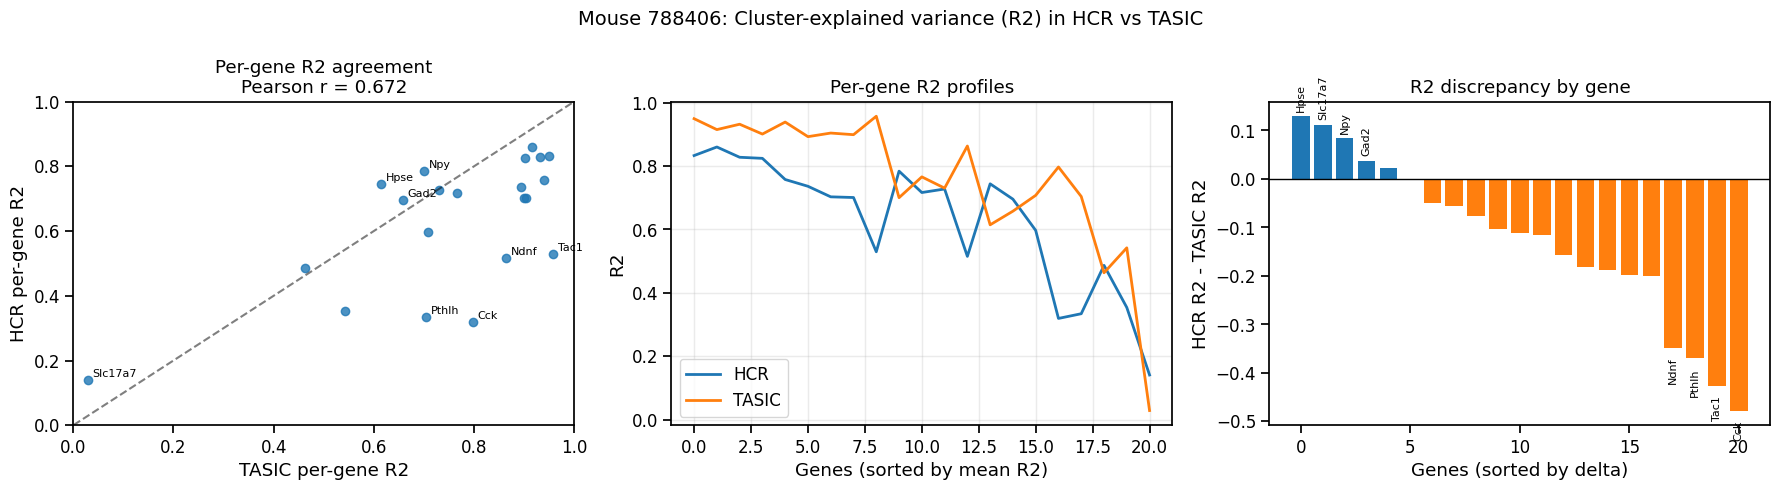

In [57]:
# Compare per-gene variance explained by clustering (R2) in HCR vs TASIC
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


def compute_gene_r2_from_labels(cxg_df: pd.DataFrame, labels: pd.Series) -> pd.Series:
    """One-way ANOVA decomposition per gene: R2 = SS_between / SS_total."""
    shared = cxg_df.index.intersection(labels.index)
    if len(shared) < 4:
        raise ValueError(f"Need at least 4 shared cells; got {len(shared)}")

    X = cxg_df.loc[shared].to_numpy(dtype=np.float64)
    y = labels.loc[shared].astype(str).to_numpy()

    classes, inv = np.unique(y, return_inverse=True)
    if len(classes) < 2:
        raise ValueError("Need at least 2 clusters to compute R2")

    grand = X.mean(axis=0)
    ss_total = ((X - grand) ** 2).sum(axis=0)

    centroids = np.zeros((len(classes), X.shape[1]), dtype=np.float64)
    for i in range(len(classes)):
        m = inv == i
        centroids[i] = X[m].mean(axis=0)

    ss_within = ((X - centroids[inv]) ** 2).sum(axis=0)
    ss_between = ss_total - ss_within
    r2 = np.where(ss_total > 1e-12, ss_between / ss_total, 0.0)

    return pd.Series(r2, index=cxg_df.columns, name="r2")


# HCR R2 (current mouse, Leiden labels from stage5 assignments)
hcr_labels = labels_assigned.astype(str).copy()
hcr_r2 = compute_gene_r2_from_labels(cxg_assigned, hcr_labels)

# TASIC R2 (aggregate all stage4 branches)
if "tasic_branch_data" not in globals() or not tasic_branch_data:
    raise ValueError("Run the Tasic loading cell first to populate tasic_branch_data")

tasic_cxg_all = []
tasic_labels_all = []
for branch, (cxg_br, labels_br) in tasic_branch_data.items():
    labels_br = labels_br.astype(str)
    shared = cxg_br.index.intersection(labels_br.index)
    if len(shared) == 0:
        continue
    tasic_cxg_all.append(cxg_br.loc[shared])
    tasic_labels_all.append(labels_br.loc[shared])

if not tasic_cxg_all:
    raise ValueError("No Tasic branch data available for R2 comparison")

tasic_cxg = pd.concat(tasic_cxg_all, axis=0)
tasic_labels = pd.concat(tasic_labels_all, axis=0)

# Keep only genes shared between datasets
shared_genes = sorted(set(hcr_r2.index).intersection(tasic_cxg.columns))
if len(shared_genes) == 0:
    raise ValueError("No shared genes between HCR and Tasic tables")

tasic_r2 = compute_gene_r2_from_labels(tasic_cxg[shared_genes], tasic_labels)
hcr_r2 = hcr_r2.loc[shared_genes]

r2_cmp = pd.DataFrame({
    "gene": shared_genes,
    "hcr_r2": hcr_r2.values,
    "tasic_r2": tasic_r2.values,
})
r2_cmp["delta_hcr_minus_tasic"] = r2_cmp["hcr_r2"] - r2_cmp["tasic_r2"]
r2_cmp["mean_r2"] = r2_cmp[["hcr_r2", "tasic_r2"]].mean(axis=1)

# Rank by absolute discrepancy
r2_cmp = r2_cmp.sort_values("delta_hcr_minus_tasic", ascending=False).reset_index(drop=True)

# Summary stats
corr = r2_cmp[["hcr_r2", "tasic_r2"]].corr().iloc[0, 1]
print(f"Shared genes: {len(r2_cmp)}")
print(f"R2 correlation (HCR vs Tasic): {corr:.3f}")
print("\nTop genes where HCR R2 > Tasic R2:")
print(r2_cmp.head(8)[["gene", "hcr_r2", "tasic_r2", "delta_hcr_minus_tasic"]].to_string(index=False))
print("\nTop genes where Tasic R2 > HCR R2:")
print(r2_cmp.tail(8).sort_values("delta_hcr_minus_tasic")[["gene", "hcr_r2", "tasic_r2", "delta_hcr_minus_tasic"]].to_string(index=False))

# Plot comparison
sns.set_context("notebook", font_scale=1.1)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1) Scatter HCR vs TASIC
ax = axes[0]
ax.scatter(r2_cmp["tasic_r2"], r2_cmp["hcr_r2"], s=36, alpha=0.8)
lims = [
    min(ax.get_xlim()[0], ax.get_ylim()[0], 0),
    max(ax.get_xlim()[1], ax.get_ylim()[1], 1),
]
ax.plot(lims, lims, "k--", alpha=0.5)
ax.set_xlim(0, min(1.0, lims[1]))
ax.set_ylim(0, min(1.0, lims[1]))
ax.set_xlabel("TASIC per-gene R2")
ax.set_ylabel("HCR per-gene R2")
ax.set_title(f"Per-gene R2 agreement\nPearson r = {corr:.3f}")

# label biggest discrepancies
label_df = pd.concat([
    r2_cmp.nlargest(4, "delta_hcr_minus_tasic"),
    r2_cmp.nsmallest(4, "delta_hcr_minus_tasic"),
]).drop_duplicates("gene")
for _, row in label_df.iterrows():
    ax.text(row["tasic_r2"] + 0.01, row["hcr_r2"] + 0.01, row["gene"], fontsize=8)

# 2) Sorted paired lines
ax = axes[1]
plot_df = r2_cmp.sort_values("mean_r2", ascending=False).reset_index(drop=True)
xs = np.arange(len(plot_df))
ax.plot(xs, plot_df["hcr_r2"], label="HCR", linewidth=2)
ax.plot(xs, plot_df["tasic_r2"], label="TASIC", linewidth=2)
ax.set_xlabel("Genes (sorted by mean R2)")
ax.set_ylabel("R2")
ax.set_title("Per-gene R2 profiles")
ax.legend()
ax.grid(alpha=0.25)

# 3) Delta barplot
ax = axes[2]
delta_plot = r2_cmp.sort_values("delta_hcr_minus_tasic", ascending=False)
colors = np.where(delta_plot["delta_hcr_minus_tasic"] >= 0, "#1f77b4", "#ff7f0e")
ax.bar(np.arange(len(delta_plot)), delta_plot["delta_hcr_minus_tasic"], color=colors)
ax.axhline(0, color="black", linewidth=1)
ax.set_xlabel("Genes (sorted by delta)")
ax.set_ylabel("HCR R2 - TASIC R2")
ax.set_title("R2 discrepancy by gene")

# annotate top discrepancies
for _, row in pd.concat([delta_plot.head(4), delta_plot.tail(4)]).iterrows():
    idx = int(delta_plot.index[delta_plot["gene"] == row["gene"]][0])
    y = row["delta_hcr_minus_tasic"]
    ax.text(idx, y + (0.01 if y >= 0 else -0.02), row["gene"], ha="center", va="bottom" if y >= 0 else "top", fontsize=8, rotation=90)

fig.suptitle(f"Mouse {MOUSE_ID}: Cluster-explained variance (R2) in HCR vs TASIC", fontsize=14)
plt.tight_layout()

r2_cmp

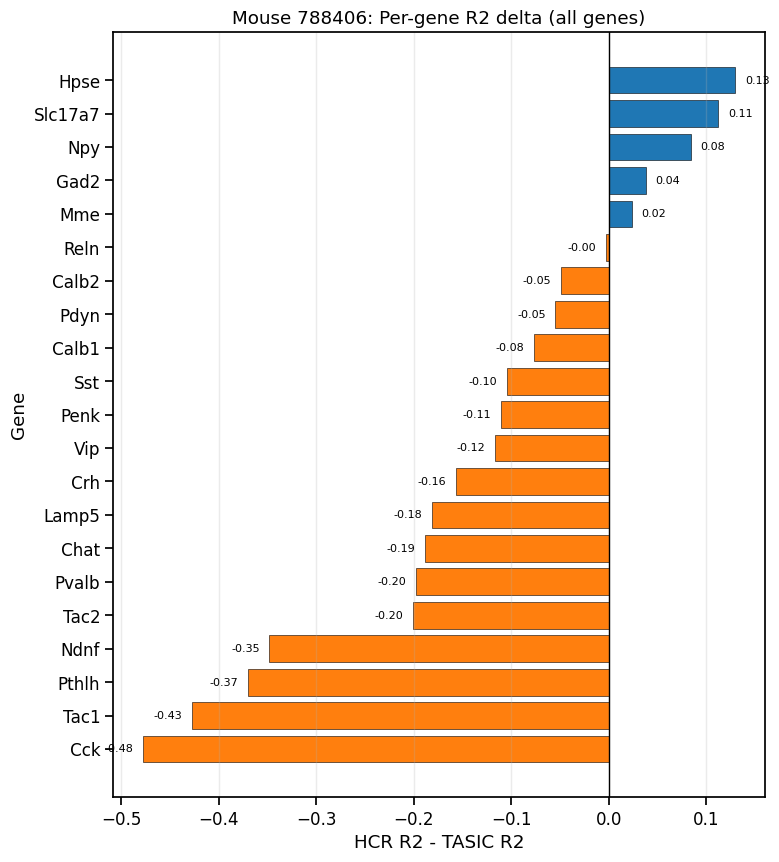

,gene,hcr_r2,tasic_r2,delta_hcr_minus_tasic
0,Cck,0.319368,0.797192,-0.477824
1,Tac1,0.529701,0.957335,-0.427634
2,Pthlh,0.334233,0.704096,-0.369863
3,Ndnf,0.515220,0.863406,-0.348186
4,Tac2,0.703055,0.904292,-0.201237
5,Pvalb,0.700917,0.899168,-0.198251
6,Chat,0.353937,0.542149,-0.188212
7,Lamp5,0.757723,0.939001,-0.181277
8,Crh,0.736343,0.892934,-0.156590
9,Vip,0.833270,0.949665,-0.116395


In [58]:
# Standalone delta plot (all genes), vertical layout
# Requires r2_cmp from the previous cell.
if "r2_cmp" not in globals() or r2_cmp.empty:
    raise ValueError("Run the R2 comparison cell first to create r2_cmp.")

import numpy as np
import matplotlib.pyplot as plt

# Sort from most TASIC-dominant (negative) to most HCR-dominant (positive)
delta_all = r2_cmp.sort_values("delta_hcr_minus_tasic", ascending=True).reset_index(drop=True)
colors = np.where(delta_all["delta_hcr_minus_tasic"] >= 0, "#1f77b4", "#ff7f0e")

fig_h = max(8, 0.42 * len(delta_all))
fig, ax = plt.subplots(figsize=(8, fig_h))

ax.barh(
    delta_all["gene"],
    delta_all["delta_hcr_minus_tasic"],
    color=colors,
    edgecolor="black",
    linewidth=0.4,
)
ax.axvline(0, color="black", linewidth=1)
ax.set_xlabel("HCR R2 - TASIC R2")
ax.set_ylabel("Gene")
ax.set_title(f"Mouse {MOUSE_ID}: Per-gene R2 delta (all genes)")
ax.grid(axis="x", alpha=0.25)

# Optional compact numeric annotations for readability on small deltas
for y, v in enumerate(delta_all["delta_hcr_minus_tasic"].values):
    x_text = v + (0.01 if v >= 0 else -0.01)
    ha = "left" if v >= 0 else "right"
    ax.text(x_text, y, f"{v:.2f}", va="center", ha=ha, fontsize=8)

plt.tight_layout()
plt.show()

delta_all[["gene", "hcr_r2", "tasic_r2", "delta_hcr_minus_tasic"]]